# Higher-order rules: what the longer rules add

## Imports

In [1]:
import ast
import os
import sys
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sys.path[:0] = [os.path.abspath(".."), os.path.abspath("../..")]

import data_helper as dh
import vis_helper as vh
import complex_vis as cv
from data_helper import base_items, check_rule_overlap, clean_items

## Parameters

In [2]:
RULE_MAX_ITEMS = 4
KINDS = ["attracts", "avoids"]
NO_SELF = True
MAX_FDR = 0.05

SCORE_COLUMN = "Pathological score"
STAGE_ORDER = ["Control", "Mild", "Severe"]
ORGAN_ORDER = ["Colon", "Duodenum"]

SHAPE_ORDER = ["ant-complex", "con-complex", "both-complex"]
SHAPE_LABELS = {
    "pairwise": "A -> B",
    "ant-complex": "A + B -> C",
    "con-complex": "A -> B + C",
    "both-complex": "A + B -> C + D",
}
CLASS_ORDER = [
    "redundant_by_simpler", "consequent_driven", "simpler_are_noise",
    "consequent_is_noise", "stronger_effect", "new",
]
CLASS_LABELS = {
    "redundant_by_simpler": "a shorter rule said it",
    "consequent_driven": "consequents do it alone",
    "simpler_are_noise": "shorter rules too weak",
    "consequent_is_noise": "backing pair too weak",
    "stronger_effect": "clearly stronger",
    "new": "nothing shorter mined",
}
GROUP_ORDER = {
    SCORE_COLUMN: STAGE_ORDER,
    "Clinical score": STAGE_ORDER,
    "Organ": ORGAN_ORDER,
    "Kind": ["attracts", "avoids"],
}

METRIC = "Lift"
MIN_GAIN = 1.1
NEW_MIN_STRENGTH = 1.3
MIN_FOVS = 5
TOP_N = 15
FOV_EXAMPLES_PER_CLASS = 1
MINING_BAR = {
    ("attracts", "Lift"): 1.2,
    ("avoids", "Lift"): 1.25,
    ("attracts", "Conviction"): 1.3,
}


TEX_CLASS_EXPORTS = {
    "attracts": "complex_attracts_verdicts.png",
    "avoids": "complex_avoids_verdicts.png",
}
TEX_GAIN_FOV_EXPORTS = {
    ("attracts", "Stronger than its best simpler rule"):
        "complex_attracts_stronger_fov.png",
    ("attracts", "More statistically significant than its best simpler rule"):
        "complex_attracts_significance_fov.png",
}
TEX_NEW_GAIN_EXPORTS = {
    "attracts": "complex_new_gain_ranking.png",
    "avoids": "complex_new_avoid_gain_ranking.png",
}
TEX_NEW_OCCURRENCE_EXPORTS = {
    ("attracts", "Epithelial, SMV -> Endothelial"):
        "complex_epithelial_smv_endothelial_occurrences.png",
}
TEX_NEW_FOV_EXPORTS = {
    ("attracts", "Epithelial, Macrophage -> Plasma"):
        "complex_epithelial_macrophage_plasma_fov.png",
    ("attracts", "Epithelial, SMV -> Endothelial"):
        "complex_epithelial_smv_endothelial_fov.png",
    ("avoids", "Muscle -> Fibroblast, Macrophage"):
        "complex_muscle_avoids_fibroblast_macrophage_fov.png",
}


## Data loading

In [3]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(
    rule_max_items=RULE_MAX_ITEMS,
    kind=None,
    max_fdr=1.0,
    informative_only=False,
)

Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.
Kept 1190114 rules at FDR <= 1.0.


Kept 1172931 rules naming no Unidentified.


Kept 1172931 rules (max_items=4, kind=None).


## Short analysis functions

In [4]:
def drop_self_rules(rules):
    if not NO_SELF:
        return rules
    repeated = [
        check_rule_overlap(base_items(a), base_items(c))
        for a, c in zip(rules["Antecedents"], rules["Consequents"])
    ]
    return rules[~pd.Series(repeated, index=rules.index)]


def attach_metadata(rules):
    rules = rules[rules["FOV"].isin(df_fovs["FOV"])]
    wanted = ["Organ", "Biopsy", "PatientID", SCORE_COLUMN]
    columns = ["FOV"] + [name for name in wanted if name not in rules]
    return rules.merge(df_fovs[columns], on="FOV", how="left")


def rule_counts(rules):
    rules = drop_self_rules(rules)
    shape = rules["Rule_Type"].map(SHAPE_LABELS)
    return pd.DataFrame({
        "rules": shape.value_counts(),
        "significant": shape[rules["Individual_FDR"] <= MAX_FDR].value_counts(),
    }).reindex([SHAPE_LABELS[s] for s in ["pairwise"] + SHAPE_ORDER])

In [5]:
def row_order(rules, split_by):
    if not split_by:
        return SHAPE_ORDER
    present = list(rules[split_by].dropna().unique())
    groups = [value for value in GROUP_ORDER.get(split_by, []) if value in present]
    groups += [value for value in present if value not in groups]
    return [(group, shape) for group in groups for shape in SHAPE_ORDER]


def class_split(rules, split_by=None, max_fdr=None):
    rules = drop_self_rules(rules)
    rules = rules[rules["Rule_Type"].isin(SHAPE_ORDER)]
    if max_fdr is not None:
        rules = rules[rules["Individual_FDR"] <= max_fdr]
    keys = ([split_by] if split_by else []) + ["Rule_Type"]
    counts = rules.groupby(keys + ["Complex_Class"]).size().unstack(fill_value=0)
    counts = counts[[name for name in CLASS_ORDER if name in counts]]
    order = row_order(rules, split_by)
    return counts.reindex([row for row in order if row in counts.index])


def show_class_split(rules, kind, split_by=None, max_fdr=None, organ=None, save=None):
    subtitle = f"Split by {split_by.lower()}" if split_by else (
        "Statistically supported rules" if max_fdr is not None else "All mined rules"
    )
    fdr = f"FDR ≤ {max_fdr}" if max_fdr is not None else "all FDR values"
    cv.plot_class_split(
        class_split(rules, split_by, max_fdr), labels=SHAPE_LABELS,
        class_labels=CLASS_LABELS, organ=organ, subtitle=subtitle,
        params=f"{kind} · {fdr}", save=save,
    )


In [6]:
def strength(rules, metric=METRIC):
    value = rules[metric].astype(float)
    if metric == "Leverage":
        return value.abs()
    return value.where(rules["Kind"] == "attracts", 1 / value.clip(lower=1e-6))


def rule_key(rules):
    ant = rules["Antecedents"].map(lambda value: " + ".join(sorted(ast.literal_eval(value))))
    con = rules["Consequents"].map(lambda value: " + ".join(sorted(ast.literal_eval(value))))
    return ant + " -> " + con


def plain_name(name):
    if not isinstance(name, str):
        return "nothing shorter was mined"
    sides = [
        ", ".join(sorted(item.replace("_CENTER", "").replace("_NEIGHBOR", "")
                         for item in side.split(" + ")))
        for side in name.split(" -> ")
    ]
    return " -> ".join(sides)


def best_parent(rules, metric=METRIC):
    keys = zip(rules["FOV"], rules["Kind"], rule_key(rules))
    found = {key: values for key, values in zip(keys, zip(
        strength(rules, metric), rules["Individual_FDR"], rules["Lift"],
        rules["Support"], rules["Conviction"],
    ))}
    details = []
    for fov, kind, simpler in zip(rules["FOV"], rules["Kind"], rules["Simpler_Rules"]):
        parents = [(*found[(fov, kind, name)], name) for name in ast.literal_eval(simpler)
                   if (fov, kind, name) in found]
        if not parents:
            details.append({"parent": np.nan, "parent_name": plain_name(None)})
            continue
        value, fdr, lift, support, conviction, name = max(
            parents, key=lambda item: item[0],
        )
        details.append({
            "parent": value, "parent_name": plain_name(name),
            "parent_rule": name, "parent_fdr": fdr,
            "parent_Lift": lift, "parent_Support": support,
            "parent_Conviction": conviction,
        })
    return pd.DataFrame(details, index=rules.index)

In [7]:
def gain_table(rules, per="rule"):
    rules = drop_self_rules(rules)
    longer = rules[rules["Rule_Type"].isin(SHAPE_ORDER)].copy()
    longer["strength"] = strength(longer)
    parent_columns = ["parent", "parent_name", "parent_rule", "parent_fdr",
                      "parent_Lift", "parent_Support", "parent_Conviction"]
    longer[parent_columns] = best_parent(rules).reindex(longer.index)[parent_columns]
    kind = rules["Kind"].iat[0]
    longer["parent"] = longer["parent"].fillna(MINING_BAR.get((kind, METRIC), 1.0))

    kept = longer[
        longer["Adds_Information"] & (longer["Individual_FDR"] <= MAX_FDR)
    ].copy()
    kept["name"] = (kept["Antecedents"].map(clean_items) + " -> "
                    + kept["Consequents"].map(clean_items))
    kept["gain"] = kept["strength"] / kept["parent"]
    support = kept.groupby("name")["FOV"].nunique()
    kept = kept[kept["name"].isin(support[support >= MIN_FOVS].index)]

    if per == "fov":
        return kept.rename(columns={"Complex_Class": "verdict"}).sort_values(
            "gain", ascending=False)

    table = kept.groupby(["name", "Rule_Type", "Complex_Class"]).agg(
        strength=("strength", "median"), parent=("parent", "median"),
        fovs=("FOV", "nunique"),
        parent_name=("parent_name", lambda values: values.mode().iat[0]),
    ).reset_index().rename(columns={"Complex_Class": "verdict"})
    table["gain"] = table["strength"] / table["parent"]
    return table[table["fovs"] >= MIN_FOVS].sort_values("gain", ascending=False)


def plot_params(kind, extra=None):
    values = [kind, f"FDR ≤ {MAX_FDR}", f"{MIN_FOVS}+ FOVs", extra]
    return " · ".join(value for value in values if value)


def metric_label(kind):
    return "Inverse lift" if kind == "avoids" and METRIC == "Lift" else METRIC


def show_gain_scatter(rows, kind, organ=None):
    cv.plot_gain_scatter(
        rows, class_labels=CLASS_LABELS, metric=metric_label(kind), min_gain=MIN_GAIN,
        organ=organ, subtitle="One point per rule occurrence",
        params=plot_params(kind, "hollow = no measured parent"),
    )


def show_gain_dumbbell(table, kind, include_new=False, organ=None, save=None):
    if not include_new:
        table = table[table["verdict"] != "new"]
    parent = "measured and lower-bound gains" if include_new else "measured gains only"
    cv.plot_gain_dumbbell(
        table, class_labels=CLASS_LABELS, metric=metric_label(kind), top_n=TOP_N,
        organ=organ, subtitle=f"Top {TOP_N} rules by gain",
        params=plot_params(kind, parent), save=save,
    )


In [8]:
def choose_fov_examples(summary, rows):
    measured = rows[rows["parent_rule"].notna()].copy()
    stronger = measured[measured["verdict"] == "stronger_effect"].head(1)

    significance = measured[measured["Individual_FDR"] < measured["parent_fdr"]].copy()
    significance["crosses_fdr"] = significance["parent_fdr"] > MAX_FDR
    significance["fdr_gain"] = ((significance["parent_fdr"] + 1e-12)
                                  / (significance["Individual_FDR"] + 1e-12))
    significance = significance.sort_values(
        ["crosses_fdr", "fdr_gain"], ascending=False,
    )
    if not stronger.empty:
        significance = significance[significance.index != stronger.index[0]]
    significance = significance.head(1)
    chosen = [("Stronger than its best simpler rule", stronger),
              ("More statistically significant than its best simpler rule", significance)]

    examples = []
    for reason, block in chosen:
        if block.empty:
            continue
        row = block.iloc[0]
        examples.append({
            "reason": reason,
            "FOV": row["FOV"], "rule": row["name"],
            "antecedent_cells": base_items(row["Antecedents"]),
            "consequent_cells": base_items(row["Consequents"]),
            "simpler_rules": [row["parent_rule"]],
            "complex_metrics": {name: row.get(name, np.nan) for name in
                                ["Lift", "Support", "Conviction",
                                 "Individual_FDR"]},
            "simpler_metrics": [{
                "Lift": row["parent_Lift"],
                "Support": row["parent_Support"],
                "Conviction": row["parent_Conviction"],
                "Individual_FDR": row["parent_fdr"],
            }],
            "detail": (f"{reason} · {METRIC.lower()} gain {row['gain']:.1f}x · "
                       f"complex FDR {row['Individual_FDR']:.3g}"),
        })
    return pd.DataFrame(examples)


def show_fov_examples(summary, rows, exports=None):
    exports = exports or {}
    examples = choose_fov_examples(summary, rows)
    if examples.empty:
        print("No measured-parent FOV examples.")
        return
    display(examples[["FOV", "rule", "detail"]])
    for _, example in examples.iterrows():
        vh.plot_rule_fov_pairs(
            [example], df_cells, df_fovs, save=exports.get(example["reason"]),
        )


def new_results(rules):
    rows = gain_table(rules, per="fov")
    rows = rows[(rows["verdict"] == "new")
                & (rows["strength"] >= NEW_MIN_STRENGTH)].copy()
    support = rows.groupby("name")["FOV"].nunique()
    rows = rows[rows["name"].isin(support[support >= MIN_FOVS].index)]
    if rows.empty:
        return pd.DataFrame(), rows
    table = rows.groupby(["name", "Rule_Type", "verdict"]).agg(
        strength=("strength", "median"), parent=("parent", "median"),
        fovs=("FOV", "nunique"),
        parent_name=("parent_name", lambda values: values.mode().iat[0]),
    ).reset_index()
    table["gain"] = table["strength"] / table["parent"]
    return table.sort_values(["fovs", "strength"], ascending=False), rows


def show_new_fov_examples(summary, rows, exports=None):
    exports = exports or {}
    names = list(summary.head(FOV_EXAMPLES_PER_CLASS)["name"])
    names += [name for name in exports if name in set(summary["name"]) and name not in names]
    examples = []
    for name in names:
        current = rows[rows["name"] == name]
        middle = current["strength"].median()
        row = current.loc[(current["strength"] - middle).abs().idxmin()]
        examples.append({
            "FOV": row["FOV"], "rule": row["name"],
            "antecedent_cells": base_items(row["Antecedents"]),
            "consequent_cells": base_items(row["Consequents"]),
            "simpler_rules": [],
            "complex_metrics": {key: row.get(key, np.nan) for key in
                                ["Lift", "Support", "Conviction"]},
            "detail": (f"New rule · effect strength ≥ {NEW_MIN_STRENGTH} · "
                       f"FDR {row['Individual_FDR']:.3g}"),
        })
    examples = pd.DataFrame(examples)
    if not examples.empty:
        display(examples[["FOV", "rule", "detail"]])
        for _, example in examples.iterrows():
            vh.plot_rule_fov_pairs(
                [example], df_cells, df_fovs, save=exports.get(example["rule"]),
            )


## Results

## Attractions

### Rule counts

In [9]:
df_results = attach_metadata(df_results)
for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    display(rule_counts(df_results[df_results["Kind"] == kind]))

#### Attracts

,rules,significant
Rule_Type,,
A -> B,4955,2745
A + B -> C,256243,106318
A -> B + C,18732,7819
A + B -> C + D,105540,39864


### Verdicts

#### Attracts

Complex_Class,redundant_by_simpler,consequent_driven,simpler_are_noise,consequent_is_noise,stronger_effect,new
Rule_Type,,,,,,
ant-complex,127619,0,84183,0,16895,27546
con-complex,7193,363,6788,203,2895,1290
both-complex,42250,1994,35669,1122,20652,3853


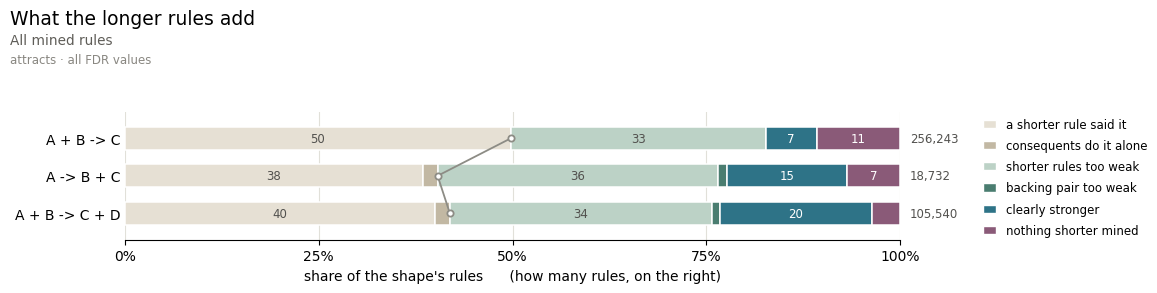

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_attracts_verdicts.png


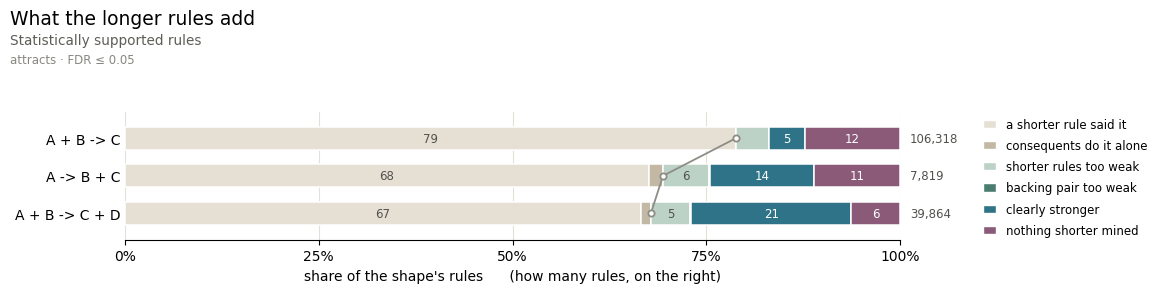

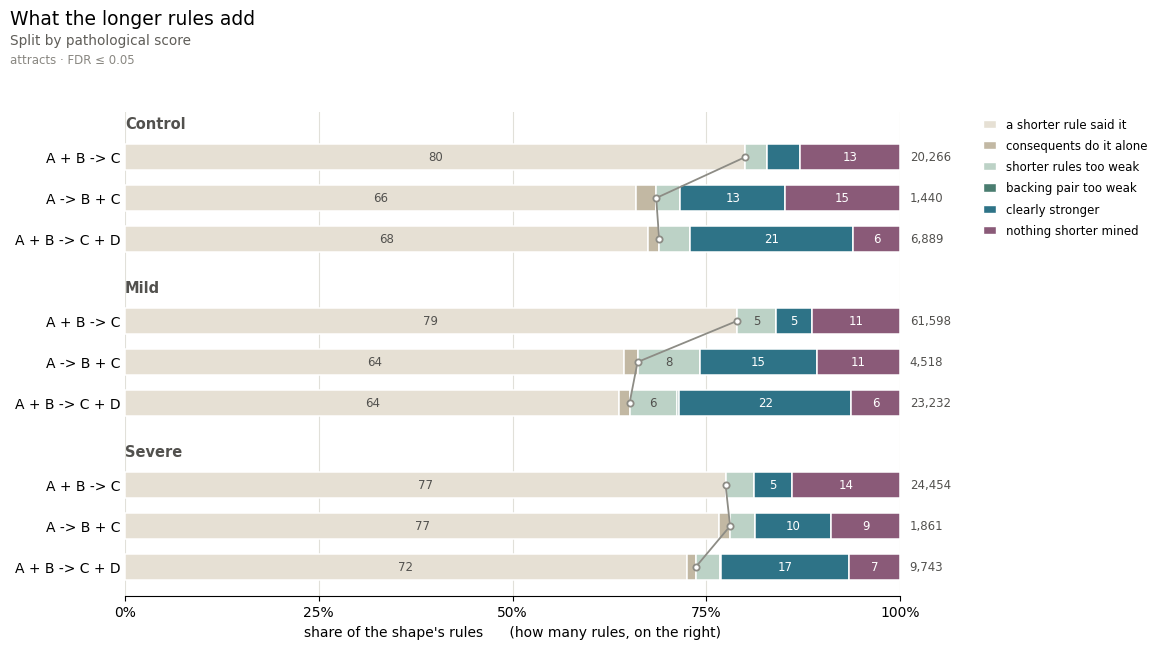

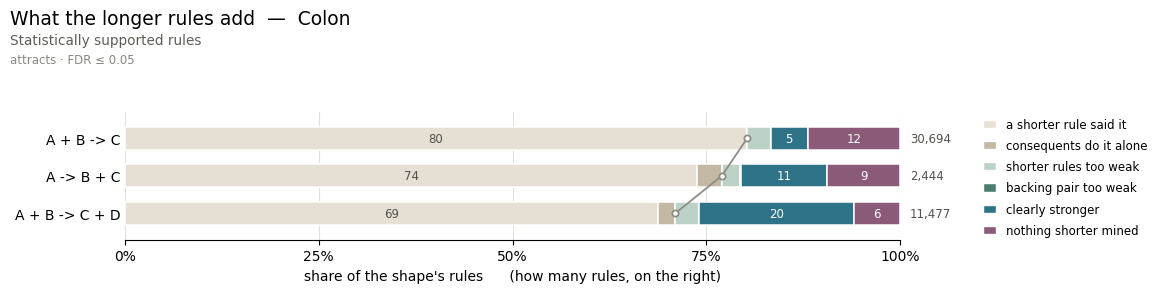

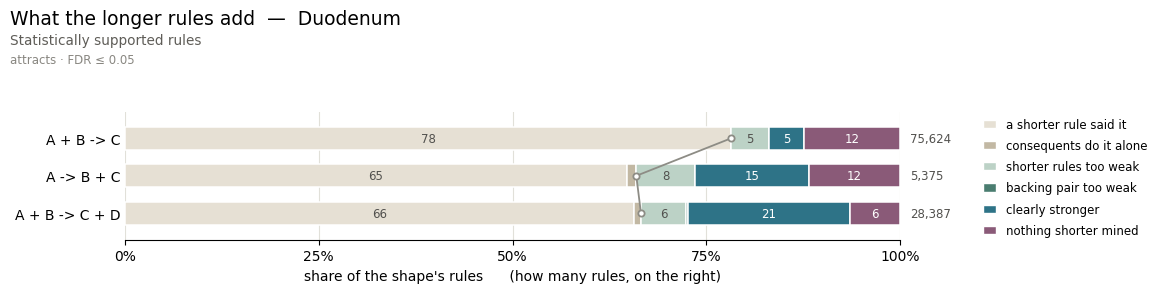

In [10]:
cv.clear_exports(TEX_CLASS_EXPORTS.values())

for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    rules = df_results[df_results["Kind"] == kind]
    display(class_split(rules))
    show_class_split(rules, kind)
    show_class_split(
        rules, kind, max_fdr=MAX_FDR, save=TEX_CLASS_EXPORTS.get(kind),
    )
    show_class_split(rules, kind, split_by=SCORE_COLUMN, max_fdr=MAX_FDR)
    for organ in ORGAN_ORDER:
        show_class_split(
            rules[rules["Organ"] == organ], kind, max_fdr=MAX_FDR, organ=organ,
        )


### Strength gains

#### Attracts

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
1757,"Epithelial, Muscle -> Paneth",ant-complex,new,4.850917,1.2,5,nothing shorter was mined,4.042431
878,"Endocrine, Epithelial -> Paneth",ant-complex,new,3.895374,1.2,6,nothing shorter was mined,3.246145
1573,"Epithelial, Macrophage, Neuroendocrine -> Endo...",ant-complex,new,3.506706,1.2,5,nothing shorter was mined,2.922255
1747,"Epithelial, Muscle -> Endocrine",ant-complex,new,3.454289,1.2,5,nothing shorter was mined,2.878574
1761,"Epithelial, Neuroendocrine -> Endocrine",ant-complex,new,3.437963,1.2,5,nothing shorter was mined,2.864969
2898,"Muscle, SMV -> Endothelial",ant-complex,new,3.230002,1.2,9,nothing shorter was mined,2.691668
1865,"Epithelial, Paneth -> Endocrine",ant-complex,new,3.159119,1.2,10,nothing shorter was mined,2.632599
3015,"Neuron, SMV -> Mesenchymal_VIM",ant-complex,new,3.128678,1.2,5,nothing shorter was mined,2.607231
2338,"Fibroblast, Plasma -> Plasma_CD38",ant-complex,new,3.039208,1.2,6,nothing shorter was mined,2.532674
2526,"ImmuneOther, SMV -> Muscle",ant-complex,new,2.993085,1.2,5,nothing shorter was mined,2.494238


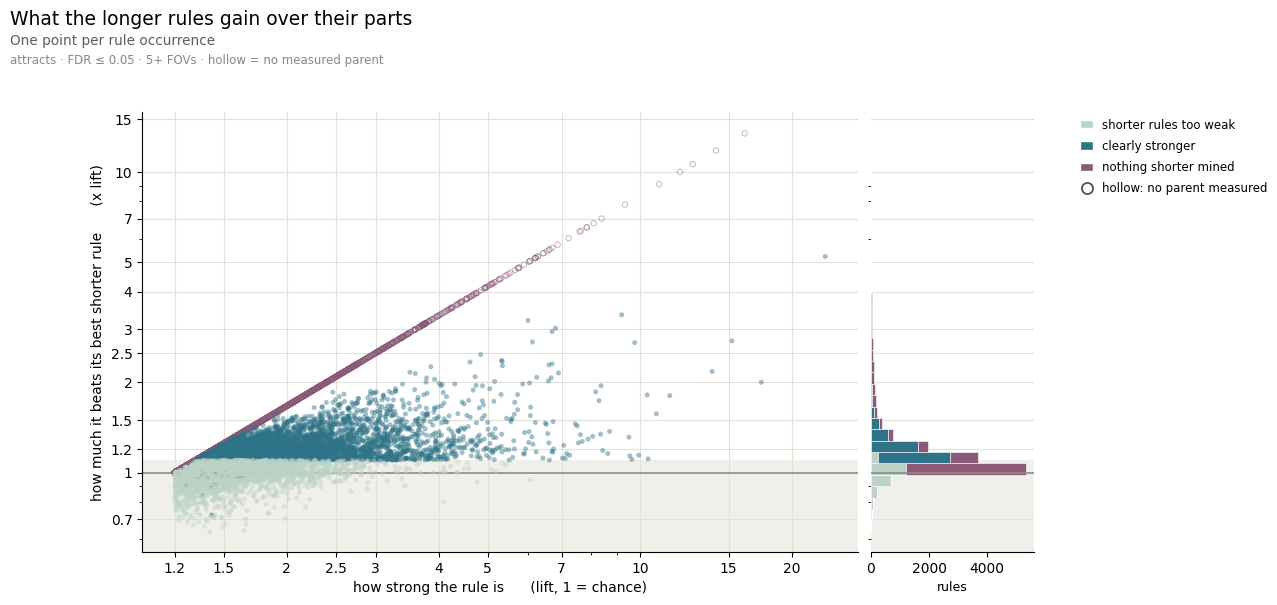

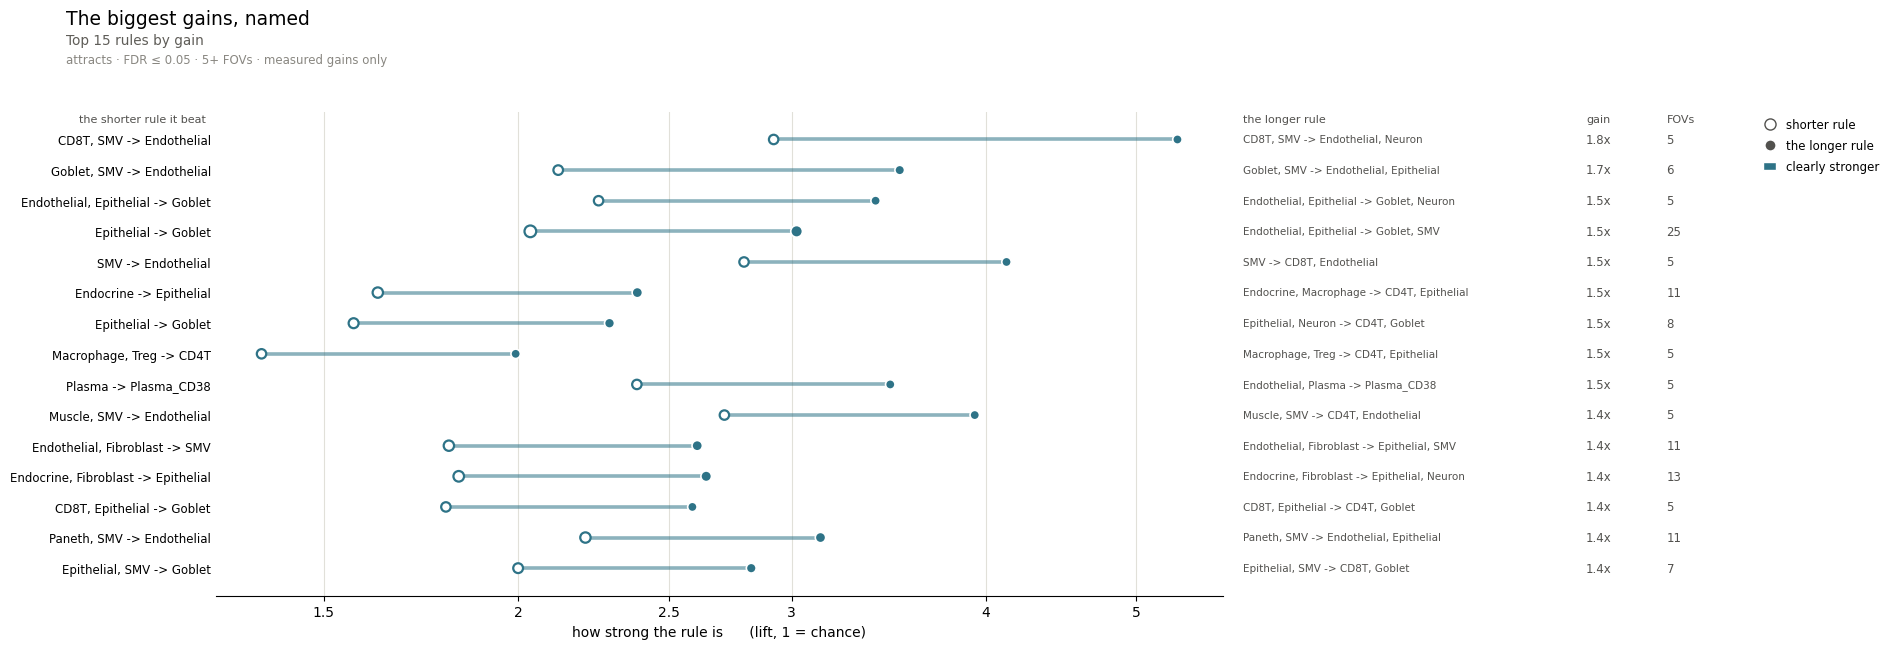

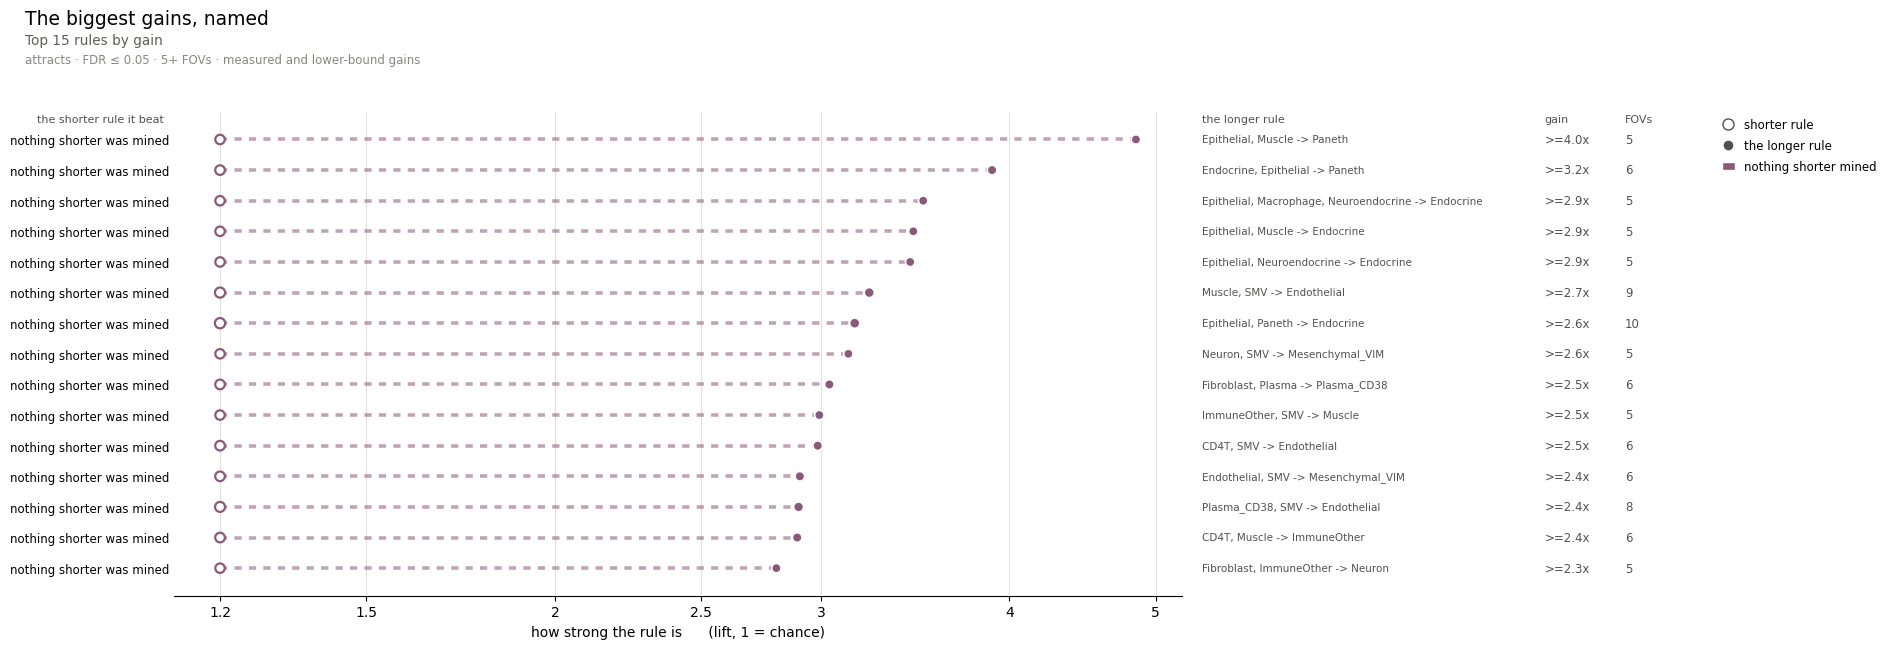

,FOV,rule,detail
0,GVHD_32_FOV_3,"Endothelial, Epithelial -> Goblet, SMV",Stronger than its best simpler rule · lift gai...
1,Control_Colon_01_FOV_7,"Endothelial, Epithelial, Macrophage -> CD8T",More statistically significant than its best s...


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_attracts_stronger_fov.png


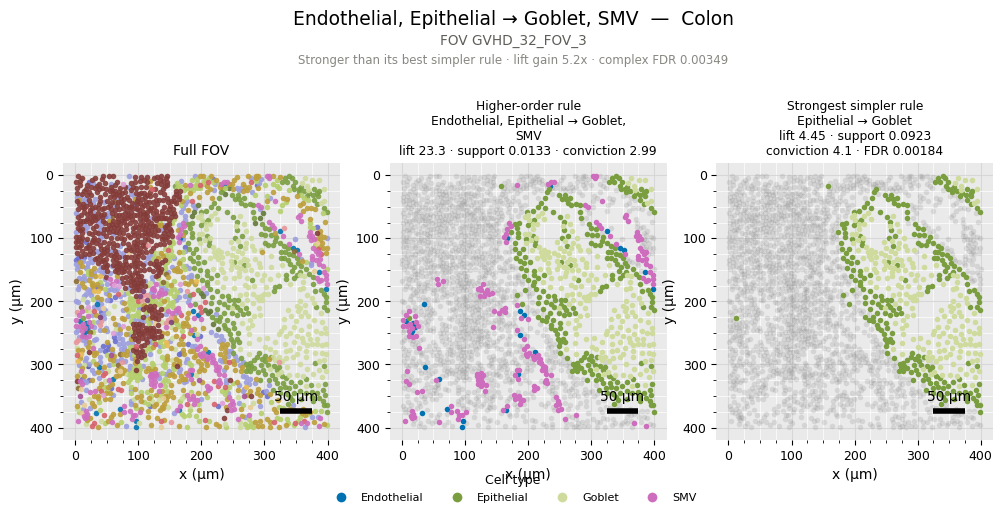

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_attracts_significance_fov.png


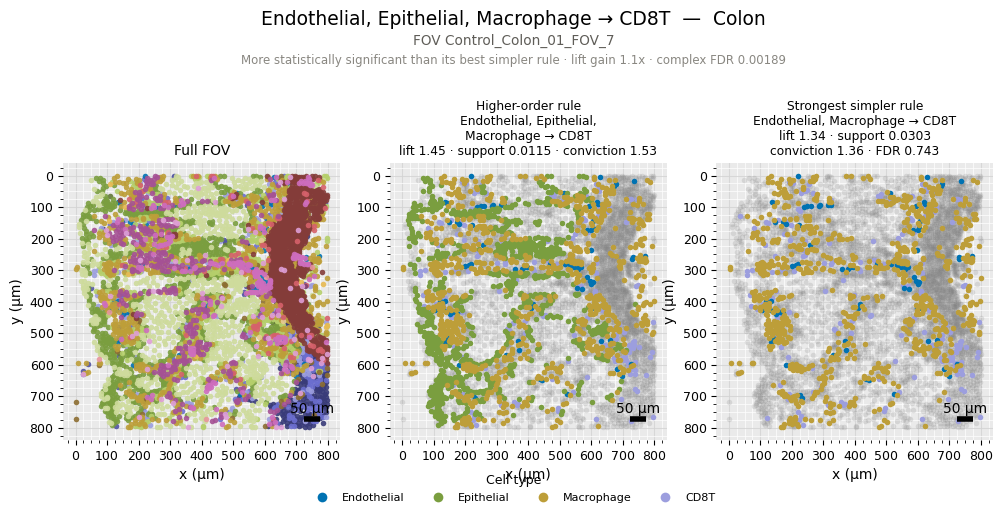

In [11]:
cv.clear_exports(TEX_GAIN_FOV_EXPORTS.values())

for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    rules = df_results[df_results["Kind"] == kind]
    gains = gain_table(rules)
    gain_rows = gain_table(rules, per="fov")
    display(gains.head(TOP_N))
    show_gain_scatter(gain_rows, kind)
    show_gain_dumbbell(gains, kind)
    show_gain_dumbbell(gains, kind, include_new=True)
    exports = {
        reason: filename
        for (export_kind, reason), filename in TEX_GAIN_FOV_EXPORTS.items()
        if export_kind == kind
    }
    show_fov_examples(gains, gain_rows, exports=exports)


### New complex rules

#### Attracts

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
44,"Epithelial, Macrophage -> Plasma",ant-complex,new,1.453840,1.2,24,nothing shorter was mined,1.211533
70,"Epithelial, SMV -> Plasma",ant-complex,new,1.431747,1.2,22,nothing shorter was mined,1.193123
36,"Epithelial, Fibroblast -> Plasma",ant-complex,new,1.433324,1.2,18,nothing shorter was mined,1.194437
20,"Endocrine, Macrophage -> Epithelial",ant-complex,new,1.825606,1.2,14,nothing shorter was mined,1.521338
66,"Epithelial, SMV -> Endothelial",ant-complex,new,2.763158,1.2,13,nothing shorter was mined,2.302632
81,"Fibroblast, Muscle -> Neuron",ant-complex,new,2.007649,1.2,13,nothing shorter was mined,1.673040
109,"Neuron, SMV -> Endothelial",ant-complex,new,2.578895,1.2,12,nothing shorter was mined,2.149079
113,"Plasma, SMV -> Endothelial",ant-complex,new,2.472250,1.2,12,nothing shorter was mined,2.060209
59,"Epithelial, Neuron -> Paneth",ant-complex,new,2.236364,1.2,12,nothing shorter was mined,1.863636
19,"Endocrine, Fibroblast -> Epithelial",ant-complex,new,1.703722,1.2,12,nothing shorter was mined,1.419768


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_new_gain_ranking.png


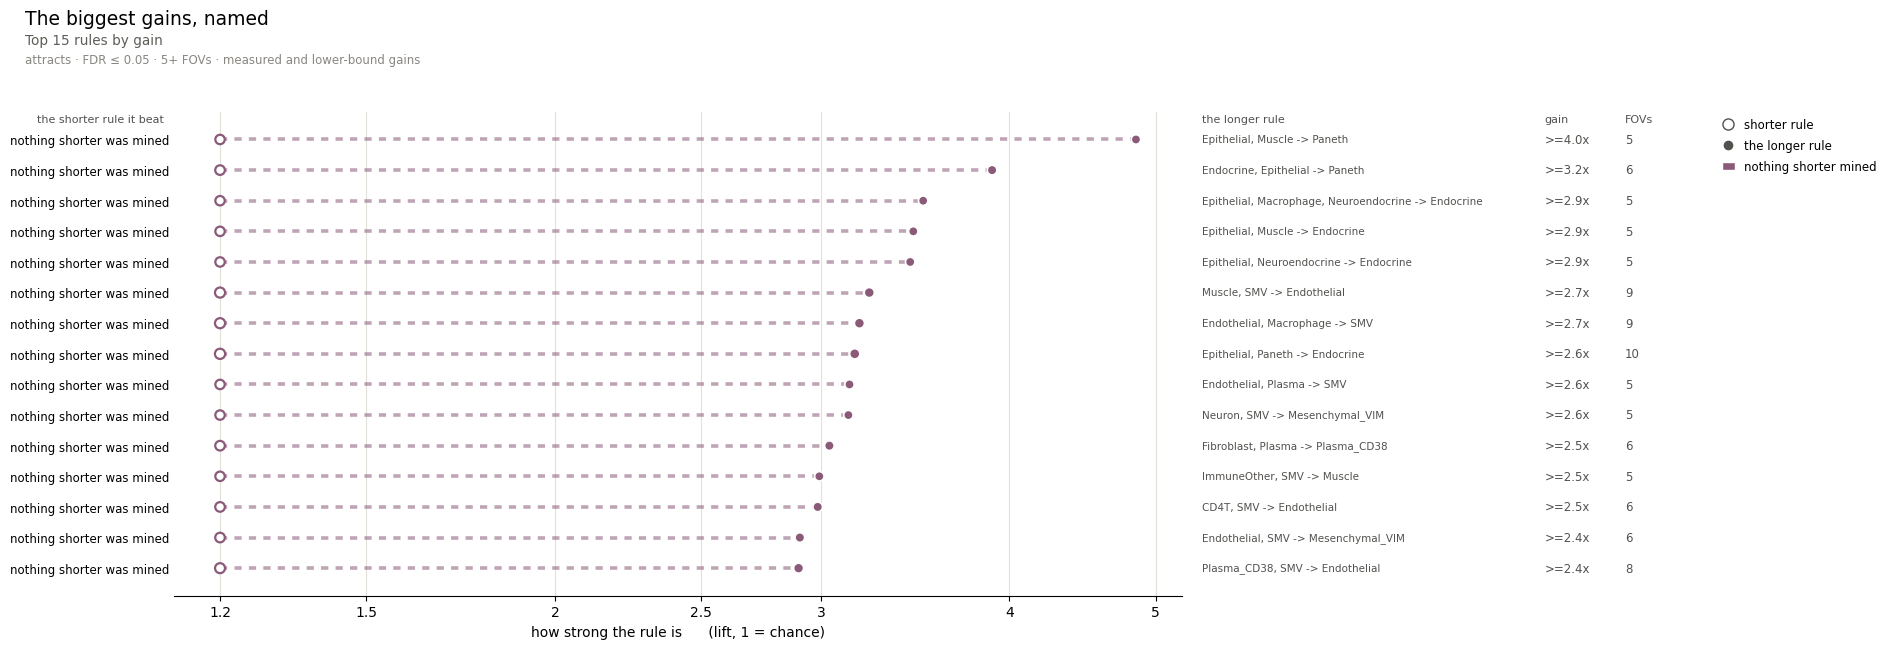

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_epithelial_smv_endothelial_occurrences.png


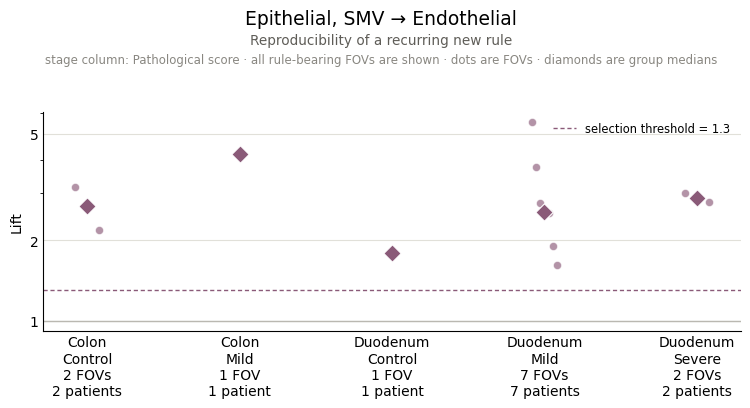

,FOV,rule,detail
0,Control_01_FOV_1,"Epithelial, Macrophage -> Plasma",New rule · effect strength ≥ 1.3 · FDR 0.0026
1,GVHD_36_FOV_1,"Epithelial, SMV -> Endothelial",New rule · effect strength ≥ 1.3 · FDR 0.0048


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_epithelial_macrophage_plasma_fov.png


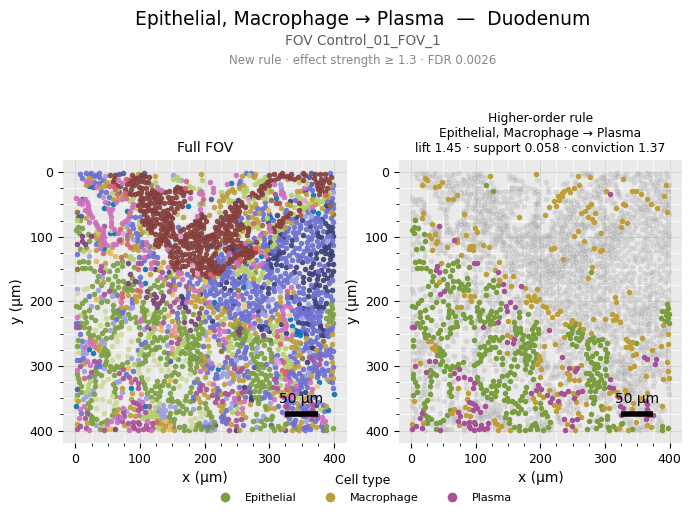

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_epithelial_smv_endothelial_fov.png


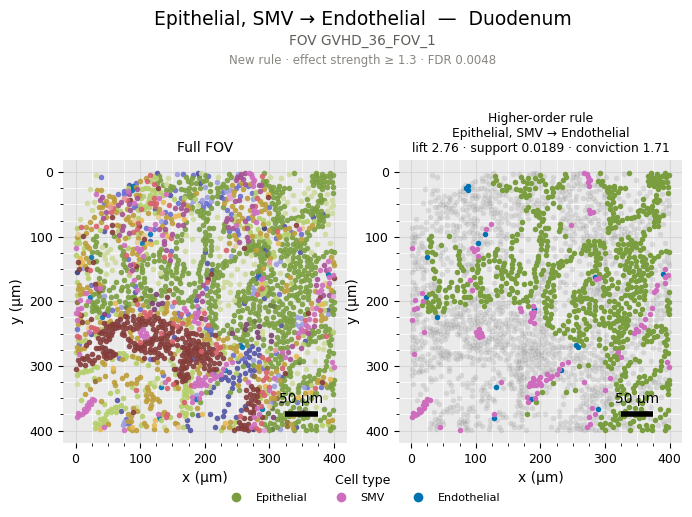

In [12]:
cv.clear_exports([
    *TEX_NEW_GAIN_EXPORTS.values(),
    *TEX_NEW_OCCURRENCE_EXPORTS.values(),
    *TEX_NEW_FOV_EXPORTS.values(),
])

for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    rules = df_results[df_results["Kind"] == kind]
    new_table, new_rows = new_results(rules)
    display(new_table.head(TOP_N))
    show_gain_dumbbell(
        new_table, kind, include_new=True, save=TEX_NEW_GAIN_EXPORTS.get(kind),
    )
    for (export_kind, rule), filename in TEX_NEW_OCCURRENCE_EXPORTS.items():
        if export_kind == kind:
            cv.plot_rule_occurrences(
                new_rows, rule, metric=METRIC, stage_column=SCORE_COLUMN,
                organ_order=ORGAN_ORDER, stage_order=STAGE_ORDER,
                threshold=NEW_MIN_STRENGTH, save=filename,
            )
    exports = {
        rule: filename
        for (export_kind, rule), filename in TEX_NEW_FOV_EXPORTS.items()
        if export_kind == kind
    }
    show_new_fov_examples(new_table, new_rows, exports=exports)

### Colon and duodenum

#### Attracts

##### Colon

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
170,"Endothelial, Macrophage -> SMV",ant-complex,new,3.466362,1.200000,6,nothing shorter was mined,2.888635
164,"Endothelial, Fibroblast -> SMV",ant-complex,new,2.984991,1.200000,5,nothing shorter was mined,2.487492
437,"Neuron, SMV -> Endothelial",ant-complex,new,2.801504,1.200000,5,nothing shorter was mined,2.334586
82,"CD8T, Epithelial, Macrophage -> Neuron",ant-complex,new,2.403595,1.200000,5,nothing shorter was mined,2.002996
349,"Fibroblast, Muscle -> Neuron",ant-complex,new,2.390655,1.200000,8,nothing shorter was mined,1.992212
242,"Epithelial, Neuron -> CD8T, Goblet",both-complex,stronger_effect,3.028014,1.984369,5,"Epithelial -> CD8T, Goblet",1.525933
124,"Endocrine, Epithelial -> Goblet, Macrophage",both-complex,stronger_effect,2.592198,1.718777,5,"Epithelial -> Goblet, Macrophage",1.508164
232,"Epithelial, Mesenchymal_VIM -> Goblet, Macrophage",both-complex,stronger_effect,2.383125,1.584887,8,Epithelial -> Goblet,1.503656
461,"SMV -> CD8T, Endothelial",con-complex,stronger_effect,4.124857,2.795846,5,SMV -> Endothelial,1.475352
434,"Muscle, SMV -> Endothelial",ant-complex,stronger_effect,5.206199,3.594438,6,SMV -> Endothelial,1.448404


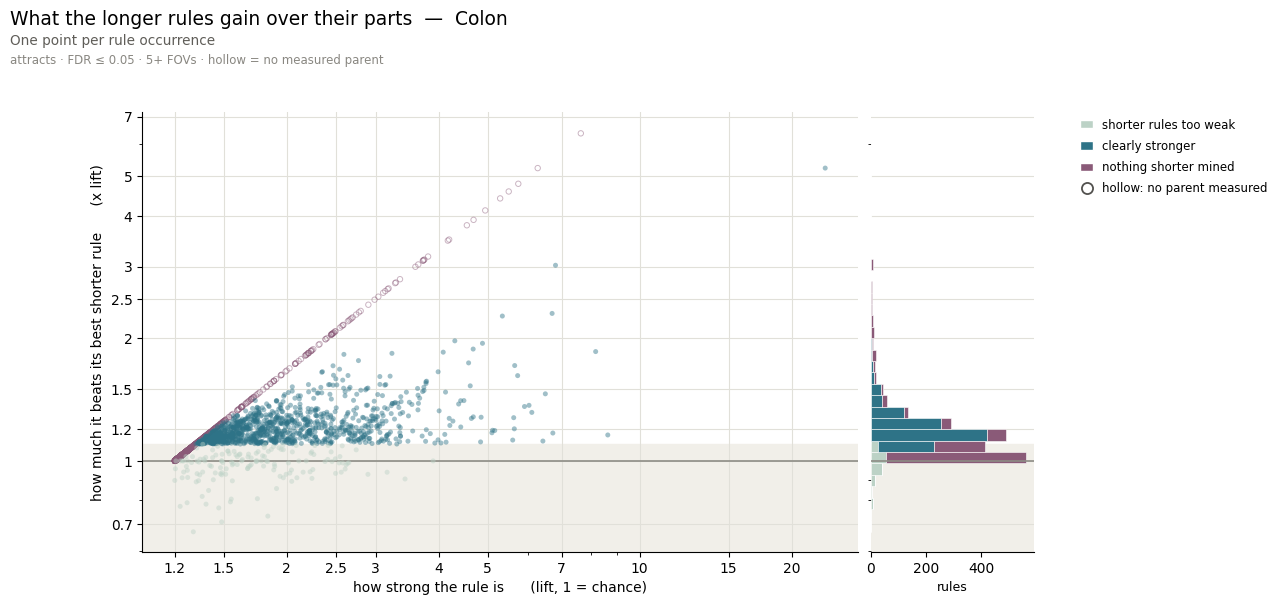

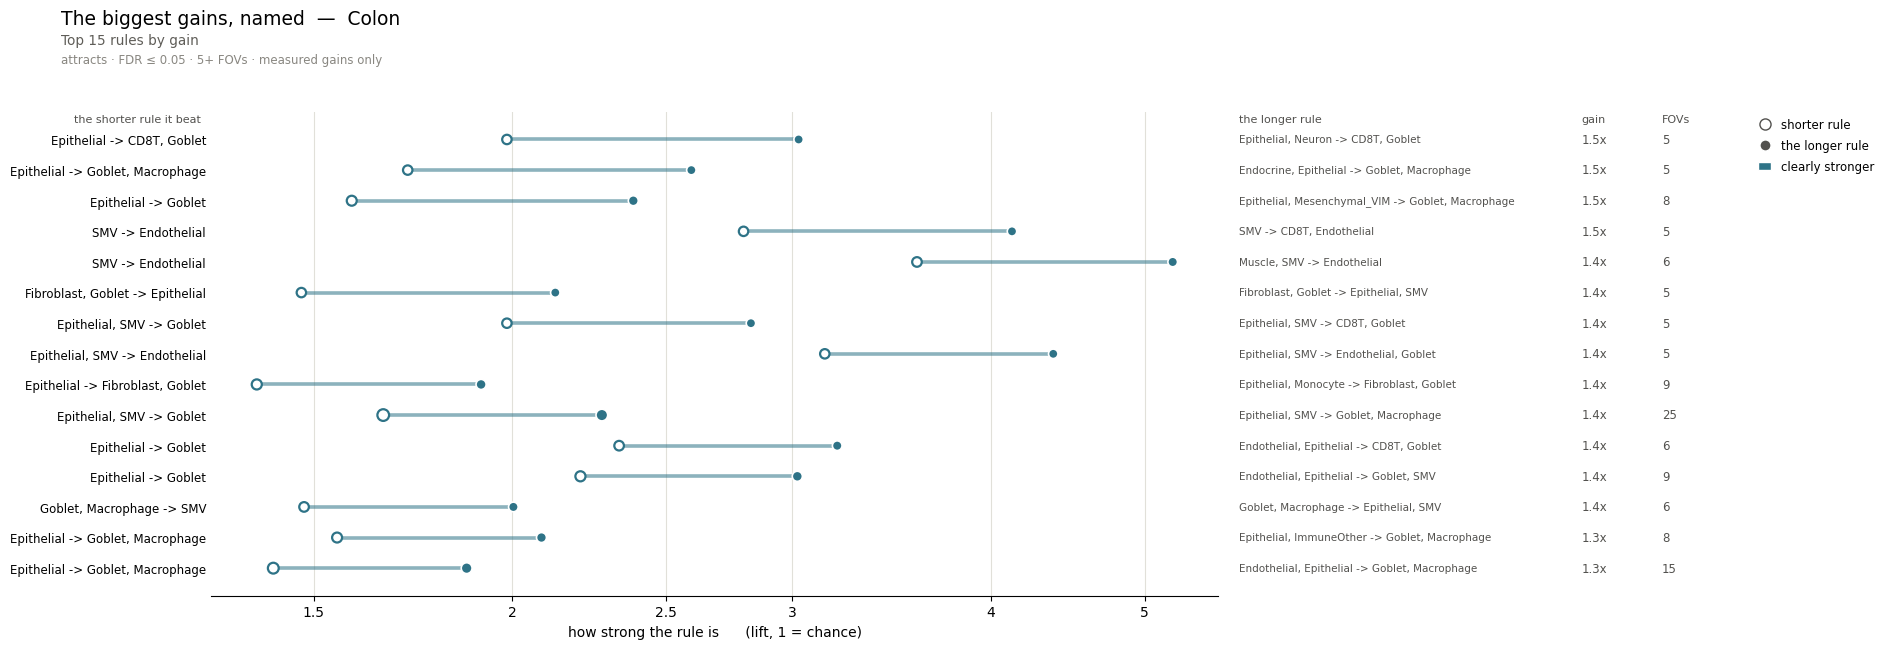

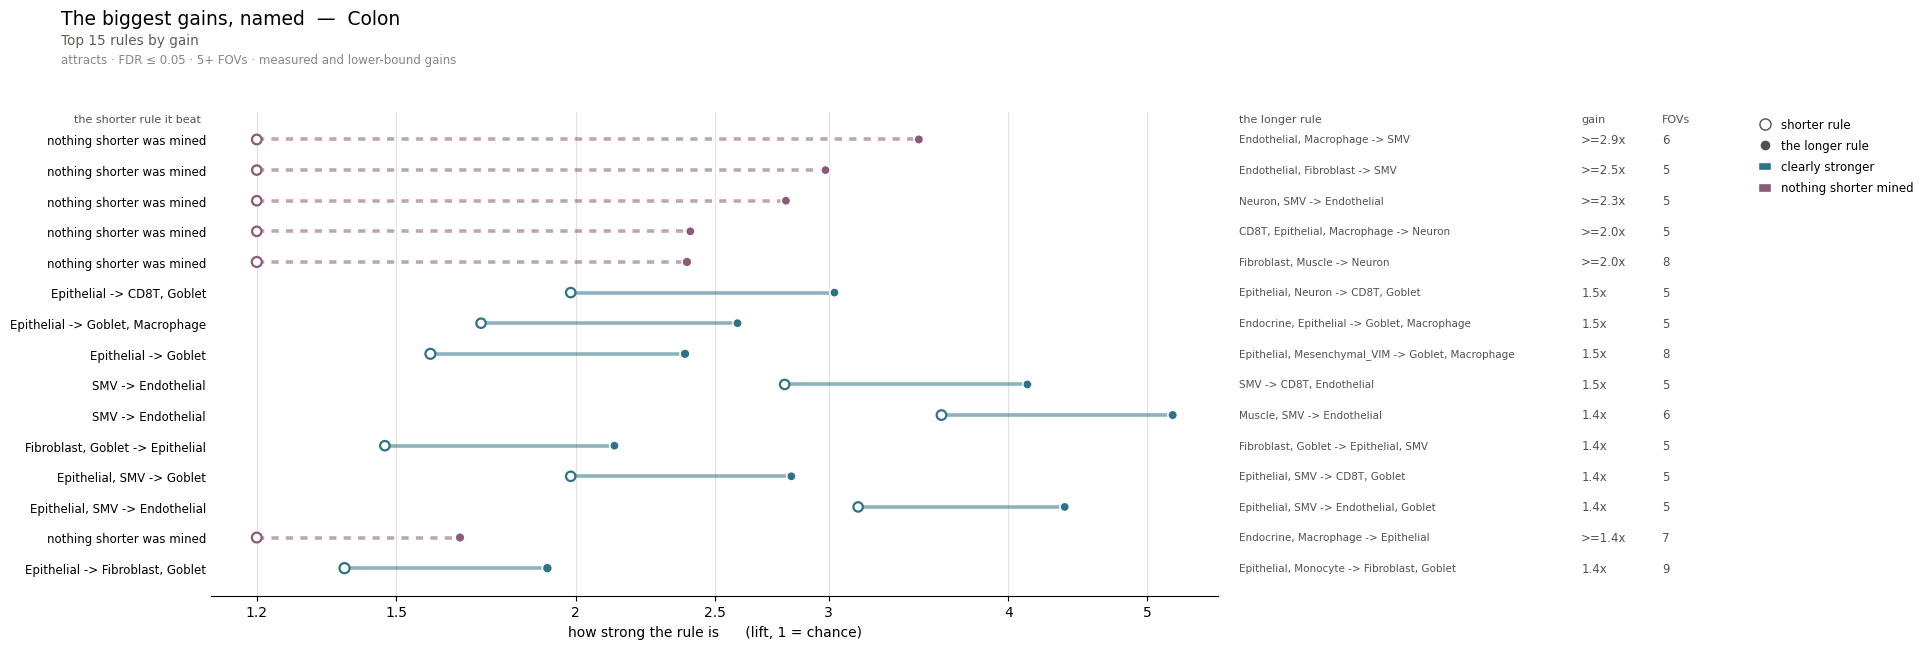

,FOV,rule,detail
0,GVHD_32_FOV_3,"Endothelial, Epithelial -> Goblet, SMV",Stronger than its best simpler rule · lift gai...
1,Control_Colon_04_FOV_2,"Fibroblast, Mast -> Epithelial, Plasma",More statistically significant than its best s...


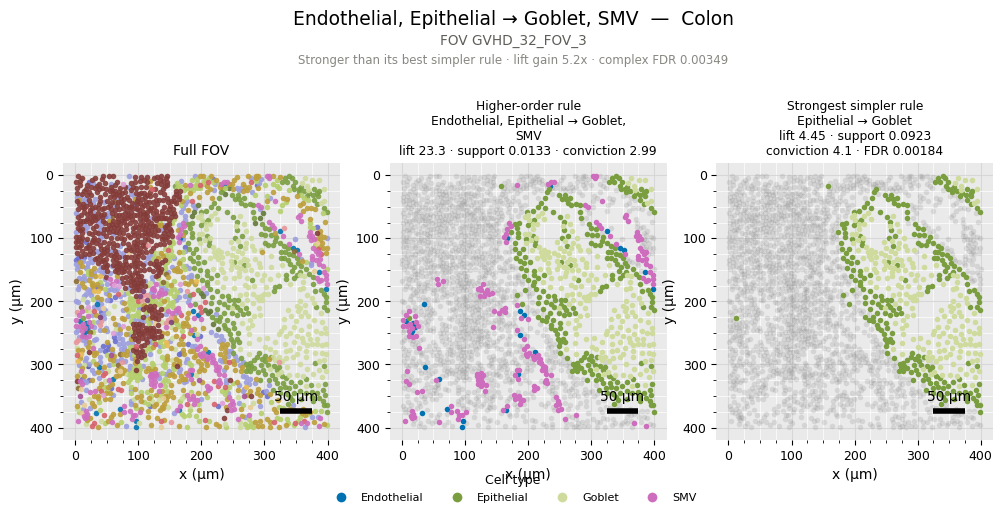

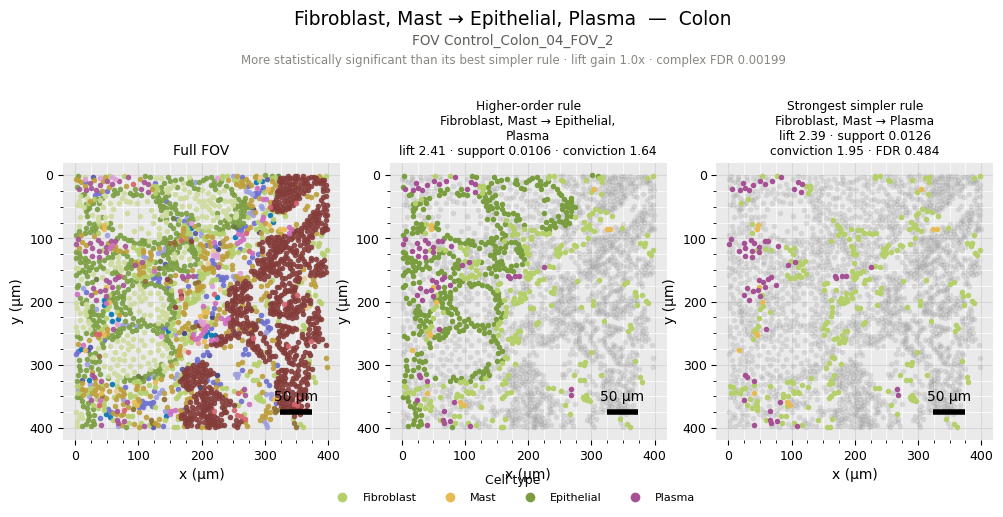

##### Duodenum

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
1010,"Epithelial, Muscle -> Paneth",ant-complex,new,4.850917,1.2,5,nothing shorter was mined,4.042431
462,"Endocrine, Epithelial -> Paneth",ant-complex,new,3.895374,1.2,6,nothing shorter was mined,3.246145
889,"Epithelial, Macrophage, Neuroendocrine -> Endo...",ant-complex,new,3.506706,1.2,5,nothing shorter was mined,2.922255
1014,"Epithelial, Neuroendocrine -> Endocrine",ant-complex,new,3.437963,1.2,5,nothing shorter was mined,2.864969
713,"Endothelial, SMV -> Mesenchymal_VIM",ant-complex,new,3.301761,1.2,5,nothing shorter was mined,2.751467
1090,"Epithelial, Paneth -> Endocrine",ant-complex,new,3.159119,1.2,10,nothing shorter was mined,2.632599
1766,"Muscle, SMV -> Endothelial",ant-complex,new,3.129256,1.2,8,nothing shorter was mined,2.607714
1406,"Fibroblast, Plasma -> Plasma_CD38",ant-complex,new,3.039208,1.2,6,nothing shorter was mined,2.532674
1524,"ImmuneOther, SMV -> Muscle",ant-complex,new,2.993085,1.2,5,nothing shorter was mined,2.494238
1768,"Muscle, SMV -> ImmuneOther",ant-complex,new,2.732794,1.2,5,nothing shorter was mined,2.277328


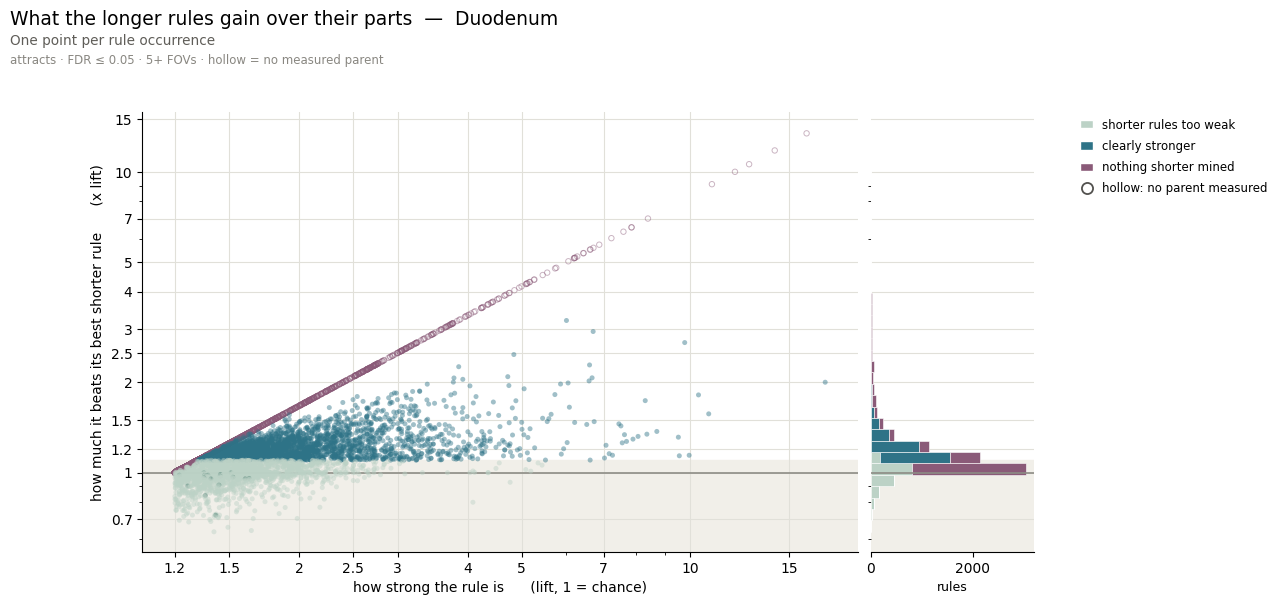

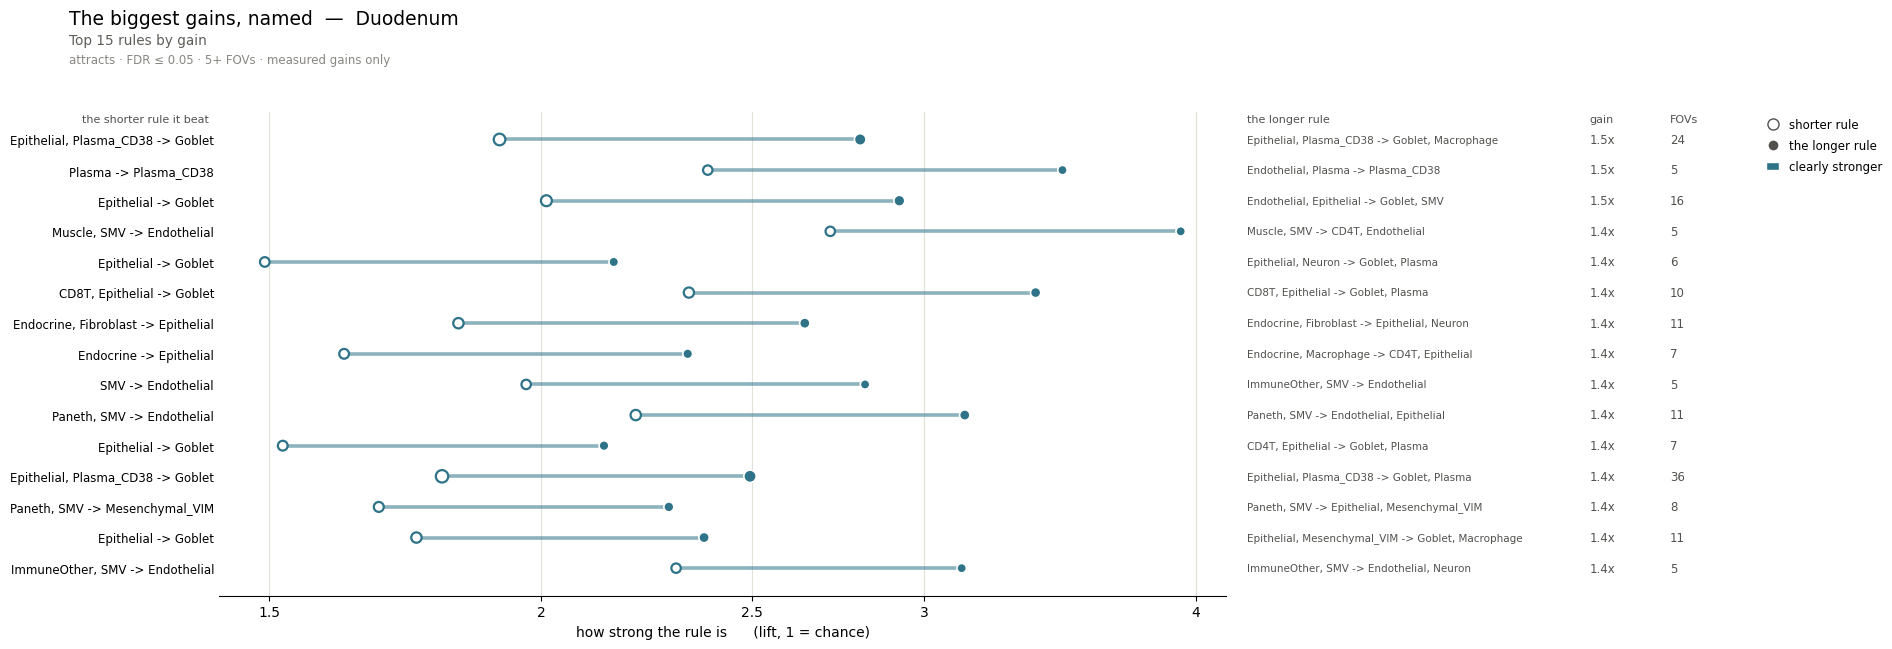

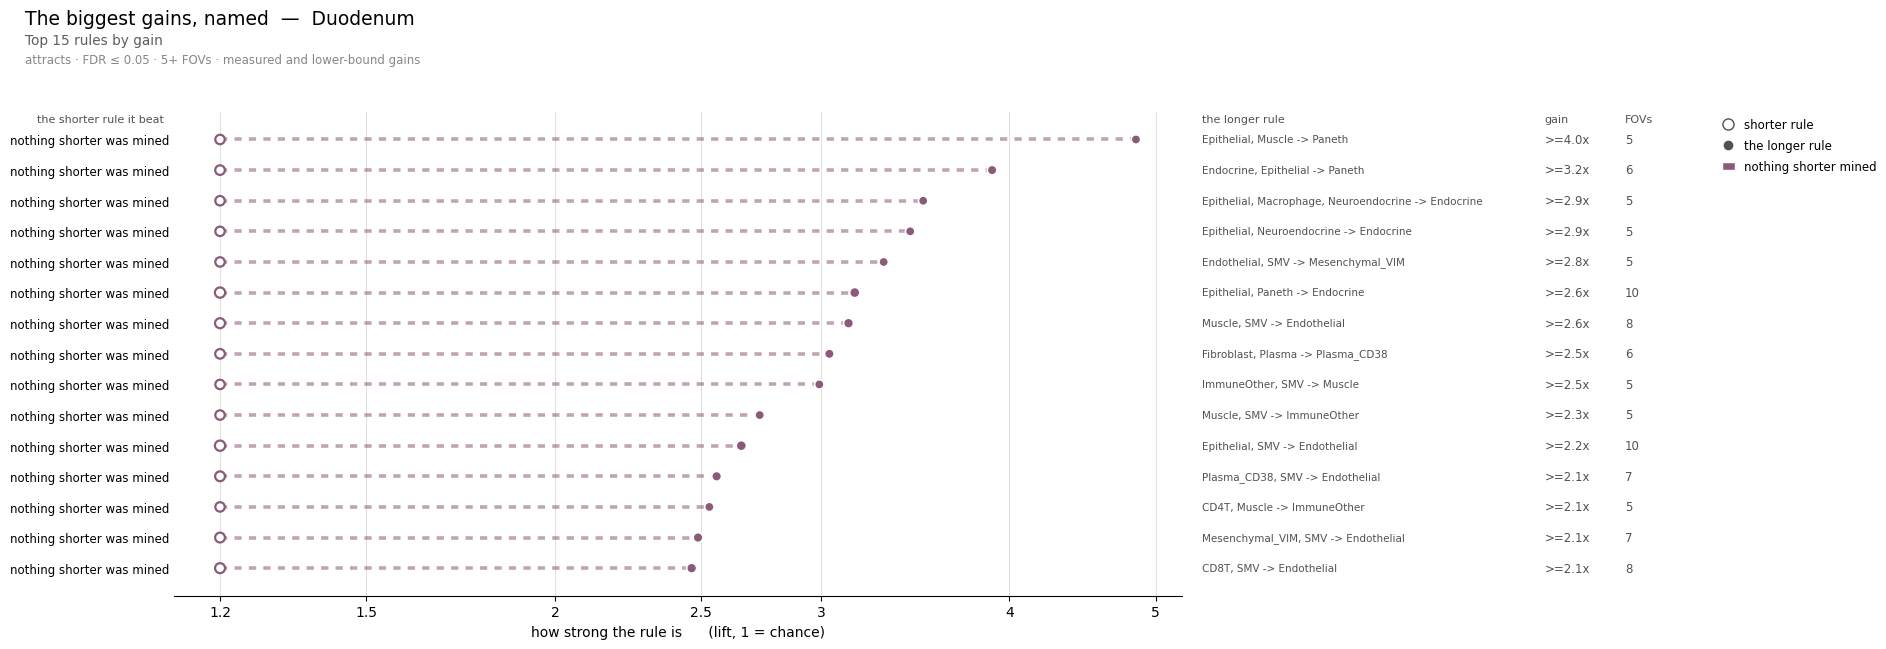

,FOV,rule,detail
0,GVHD_36_FOV_2,"Epithelial, Mesenchymal_VIM -> Goblet, SMV",Stronger than its best simpler rule · lift gai...
1,GVHD_09_FOV_3,"Fibroblast, ImmuneOther -> Epithelial, Neuron",More statistically significant than its best s...


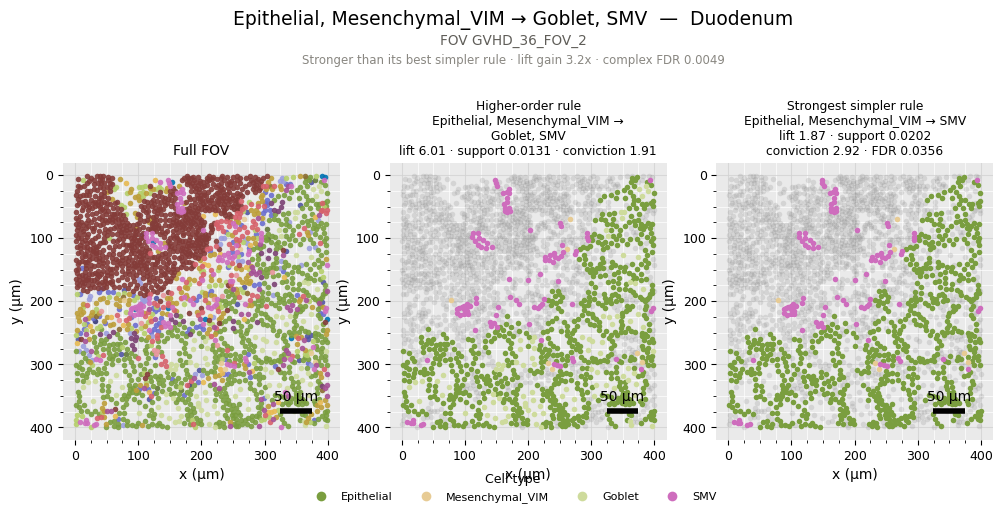

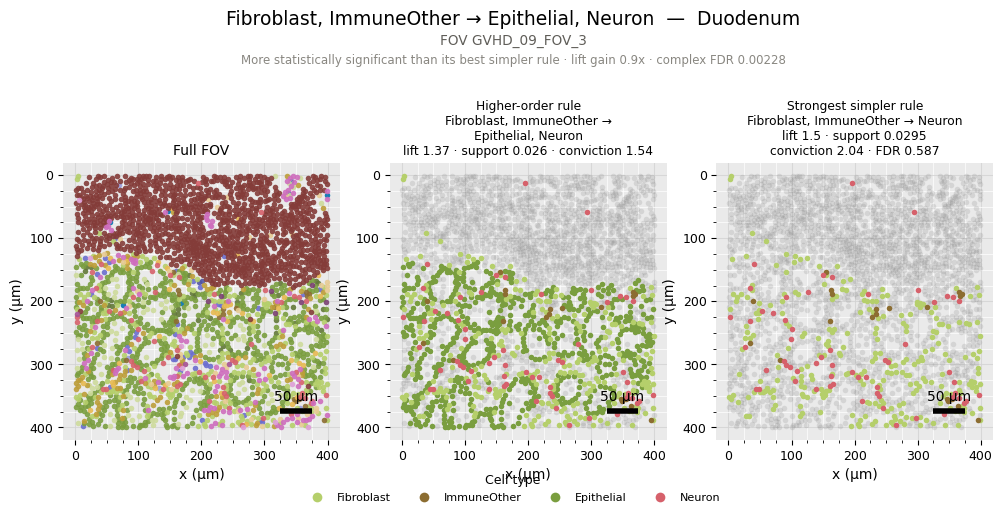

In [13]:
for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    rules = df_results[df_results["Kind"] == kind]
    for organ in ORGAN_ORDER:
        display(Markdown(f"##### {organ}"))
        organ_rules = rules[rules["Organ"] == organ]
        organ_gains = gain_table(organ_rules)
        organ_rows = gain_table(organ_rules, per="fov")
        display(organ_gains.head(TOP_N))
        show_gain_scatter(organ_rows, kind, organ=organ)
        show_gain_dumbbell(organ_gains, kind, organ=organ)
        show_gain_dumbbell(organ_gains, kind, include_new=True, organ=organ)
        show_fov_examples(organ_gains, organ_rows)


## Avoidances (negative spatial rules)


### Rule counts

,rules,significant
Rule_Type,,
A -> B,7516,4902
A + B -> C,98001,48745
A -> B + C,91559,36417
A + B -> C + D,107799,37329


### Verdicts

Complex_Class,redundant_by_simpler,consequent_driven,simpler_are_noise,consequent_is_noise,stronger_effect,new
Rule_Type,,,,,,
ant-complex,46414,0,31426,0,12940,7221
con-complex,29234,1306,30438,261,27527,2793
both-complex,46810,4447,42398,1036,11348,1760


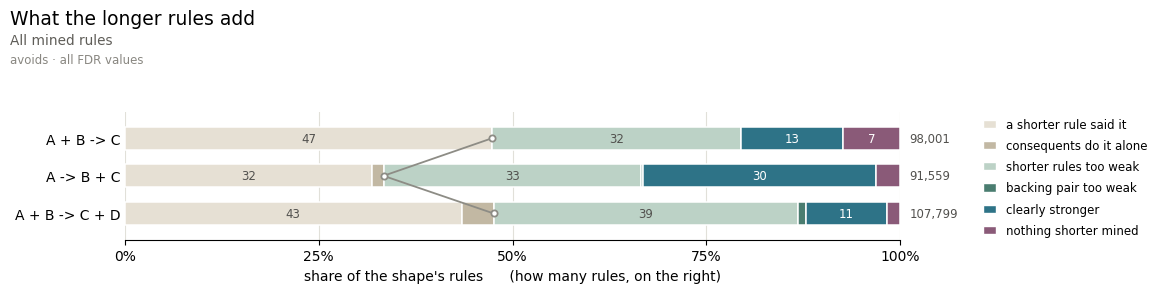

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_avoids_verdicts.png


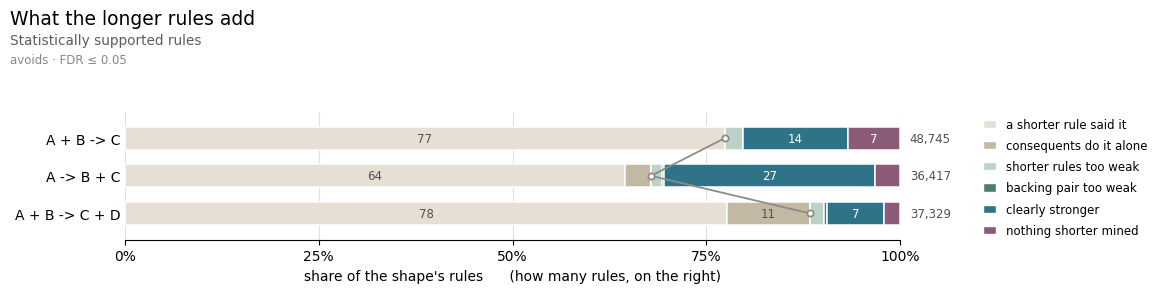

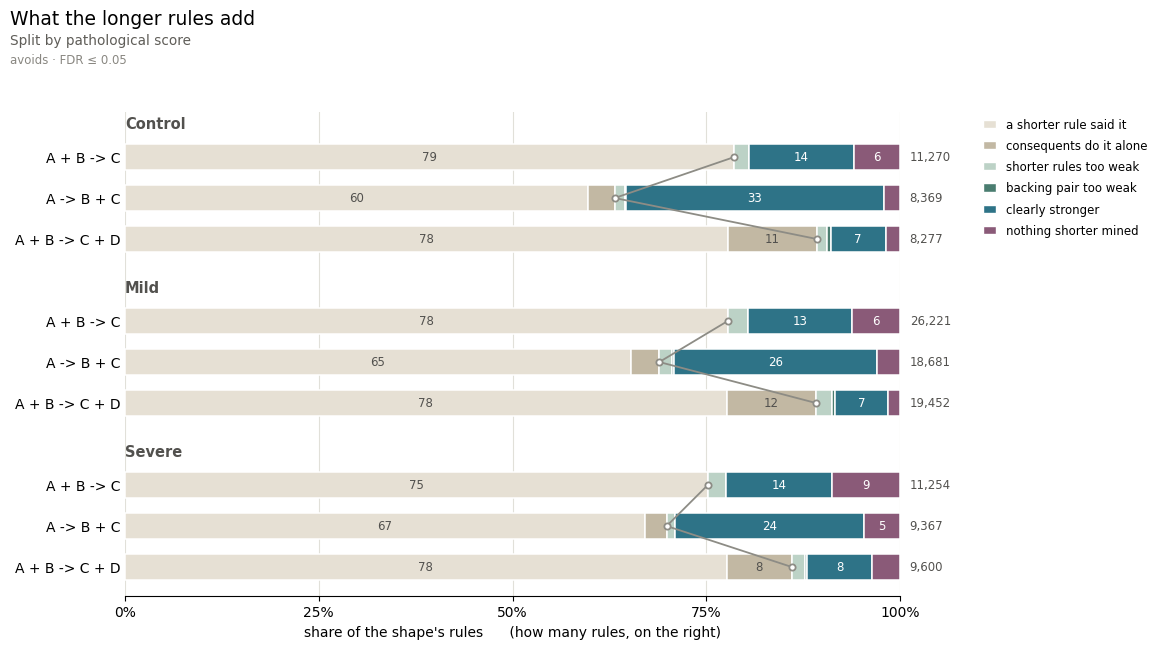

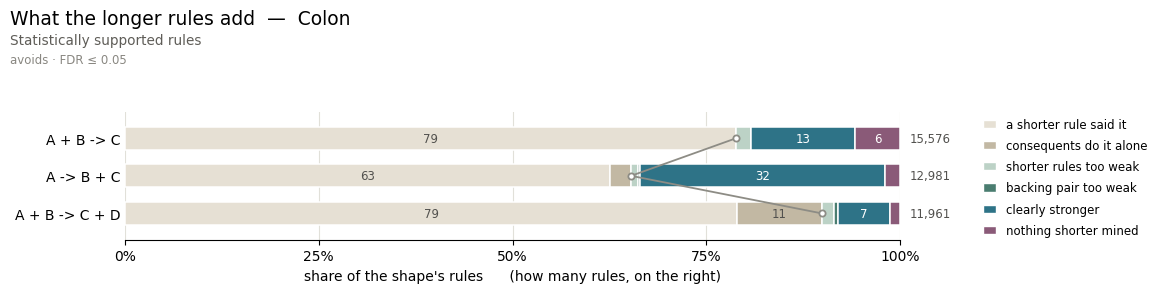

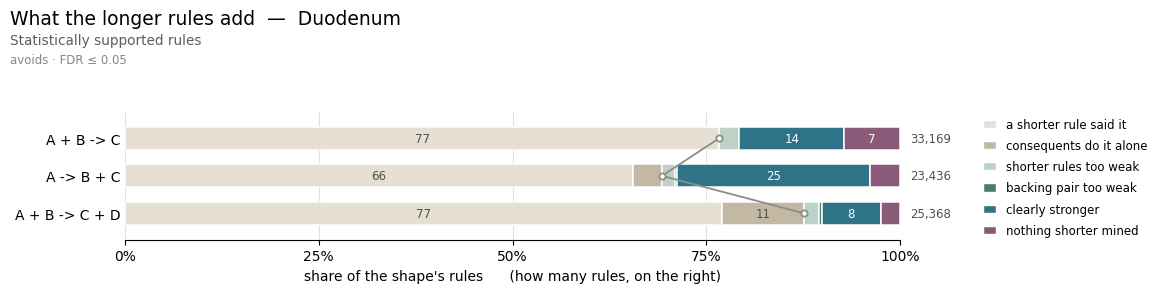

### Strength gains

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
465,"Epithelial, SMV -> Muscle",ant-complex,stronger_effect,1000000.000000,12.985530,14,Epithelial -> Muscle,77008.791879
1269,"Muscle -> Epithelial, Plasma",con-complex,stronger_effect,1000000.000000,13.111522,11,Muscle -> Epithelial,76268.798884
1420,"Muscle, Neuron -> Goblet",ant-complex,stronger_effect,1000000.000000,14.630191,10,Muscle -> Goblet,68351.805487
1427,"Muscle, Neuron -> Plasma, SMV",both-complex,stronger_effect,500003.421242,7.764066,6,"Muscle -> Plasma, SMV",64399.689548
441,"Epithelial, Goblet -> Muscle",ant-complex,stronger_effect,1000000.000000,16.060166,43,Epithelial -> Muscle,62265.856494
1136,"Muscle -> CD4T, Epithelial",con-complex,stronger_effect,500006.117211,8.658442,6,Muscle -> Epithelial,57747.816632
1274,"Muscle -> Epithelial, SMV",con-complex,stronger_effect,500067.051139,10.309258,10,Muscle -> Epithelial,48506.599704
1323,"Muscle -> Goblet, Neuron",con-complex,stronger_effect,500008.319774,11.317651,6,Muscle -> Goblet,44179.512780
1206,"Muscle -> CD8T, Goblet",con-complex,stronger_effect,1000000.000000,23.634847,11,Muscle -> Goblet,42310.406601
1324,"Muscle -> Goblet, Plasma",con-complex,stronger_effect,1000000.000000,23.634847,13,Muscle -> Goblet,42310.406601


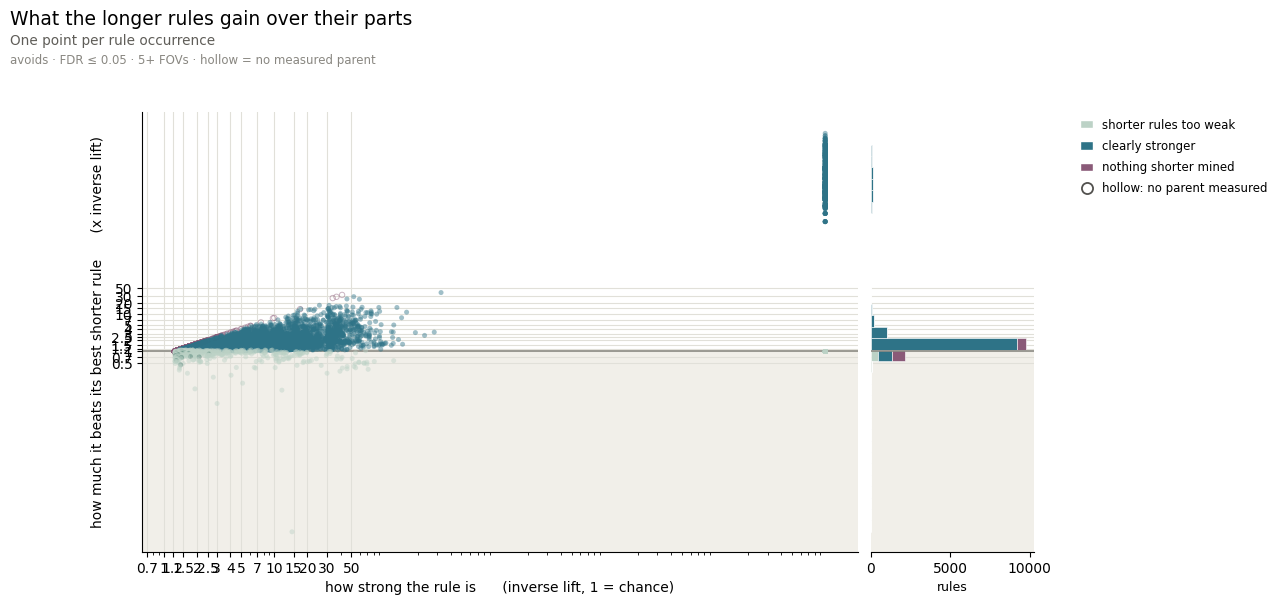

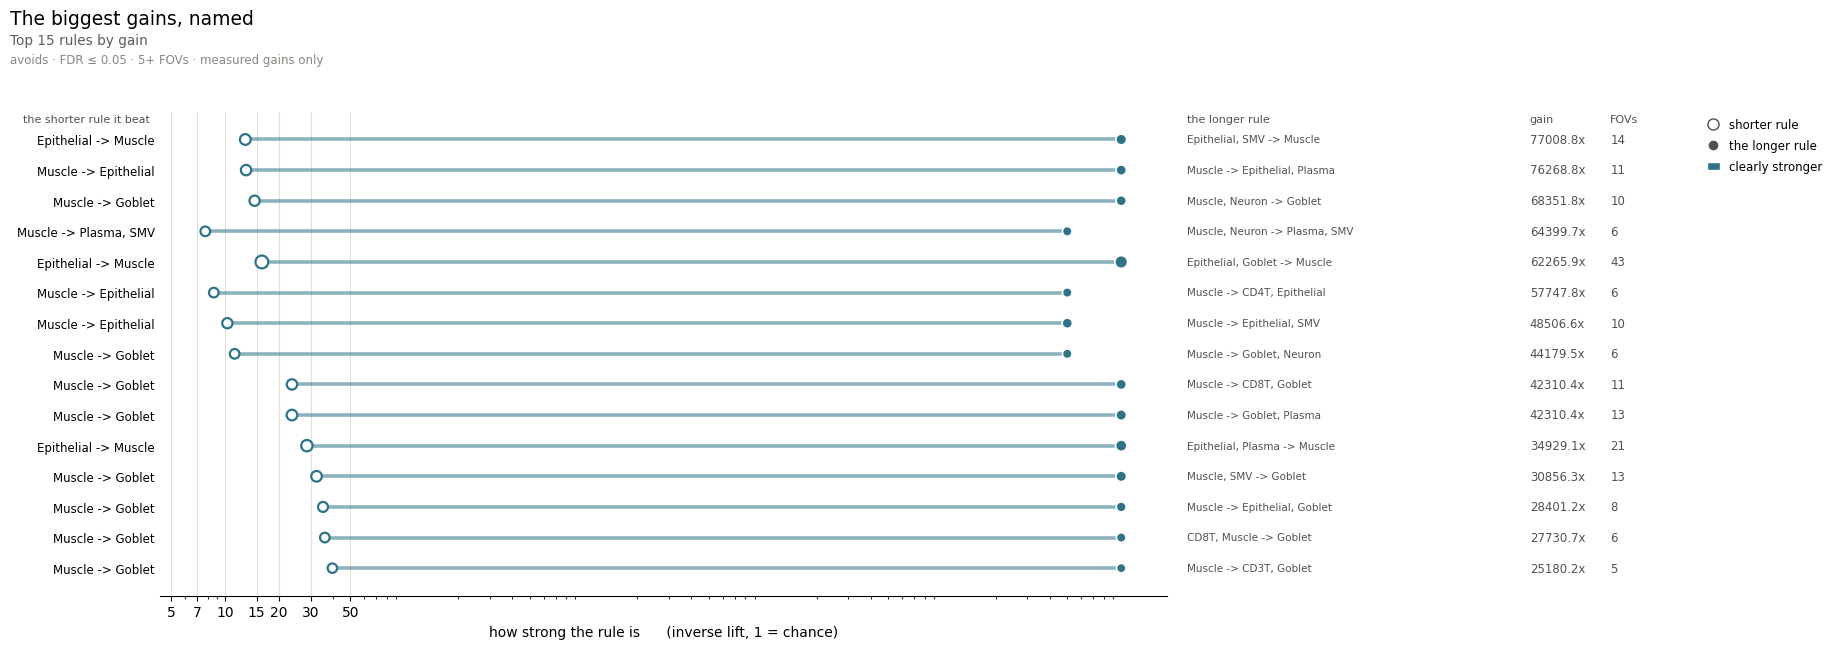

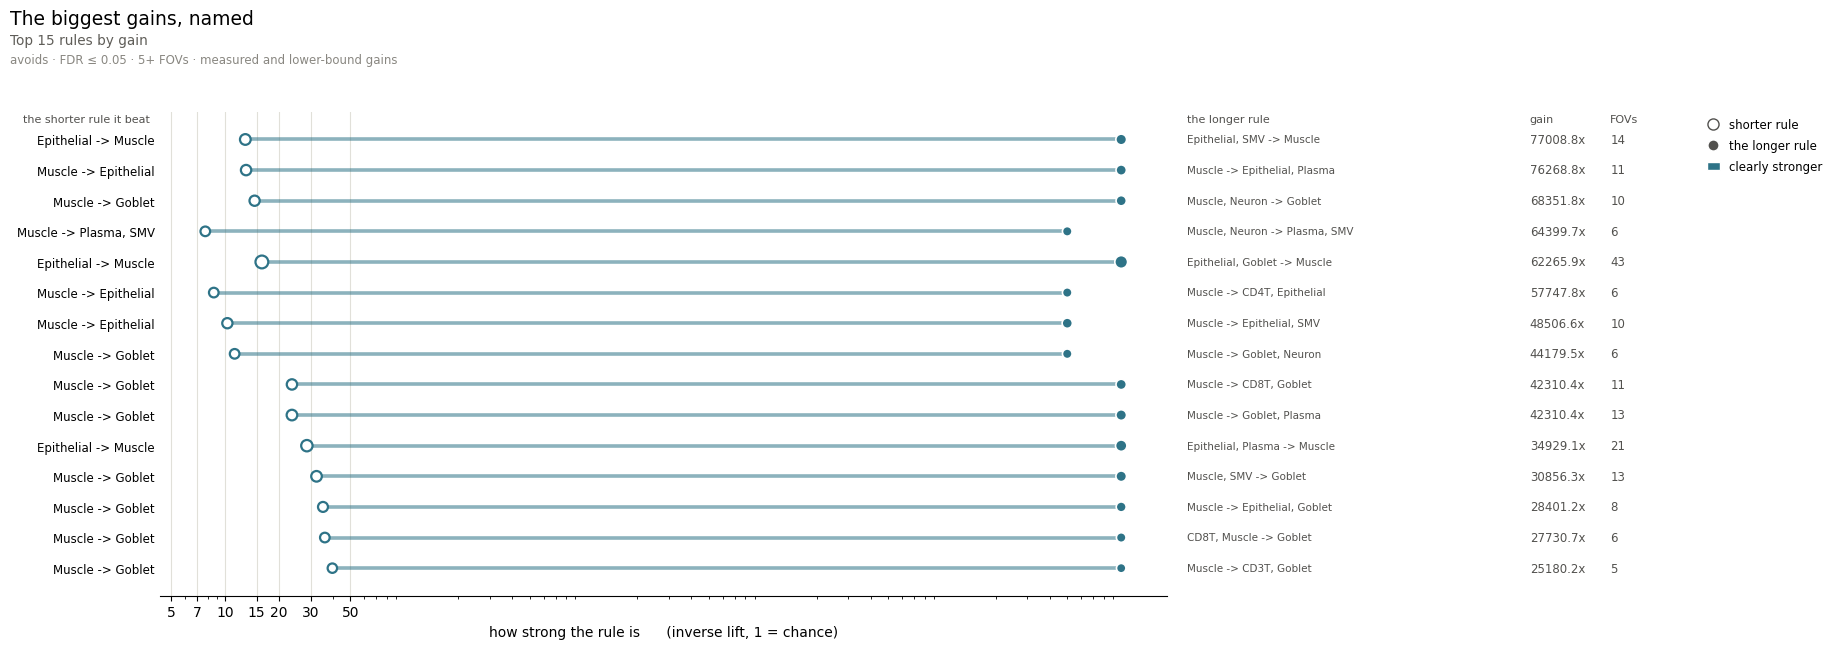

,FOV,rule,detail
0,Control_Colon_04_FOV_1,"Muscle -> Fibroblast, Monocyte",Stronger than its best simpler rule · lift gai...
1,Control_Colon_04_FOV_5,"CD4T, Endothelial, SMV -> Epithelial",More statistically significant than its best s...


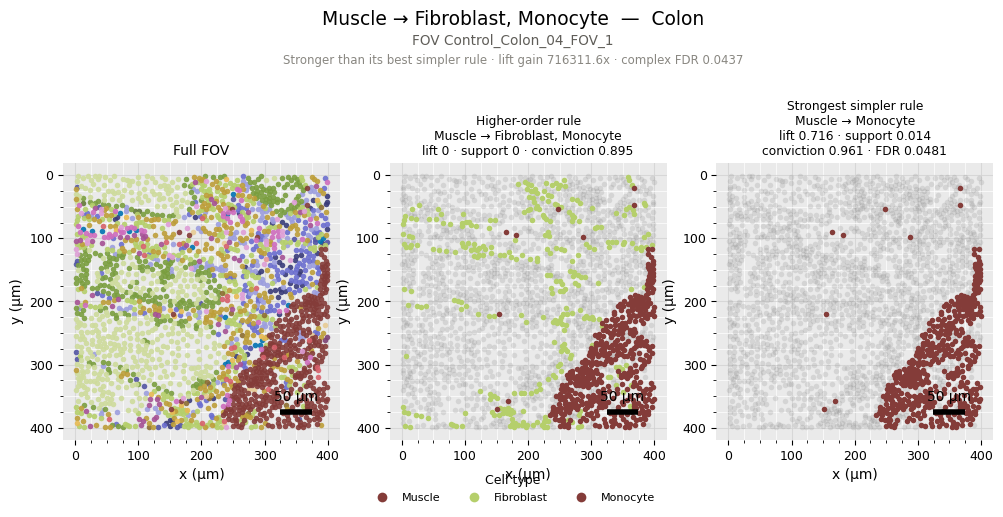

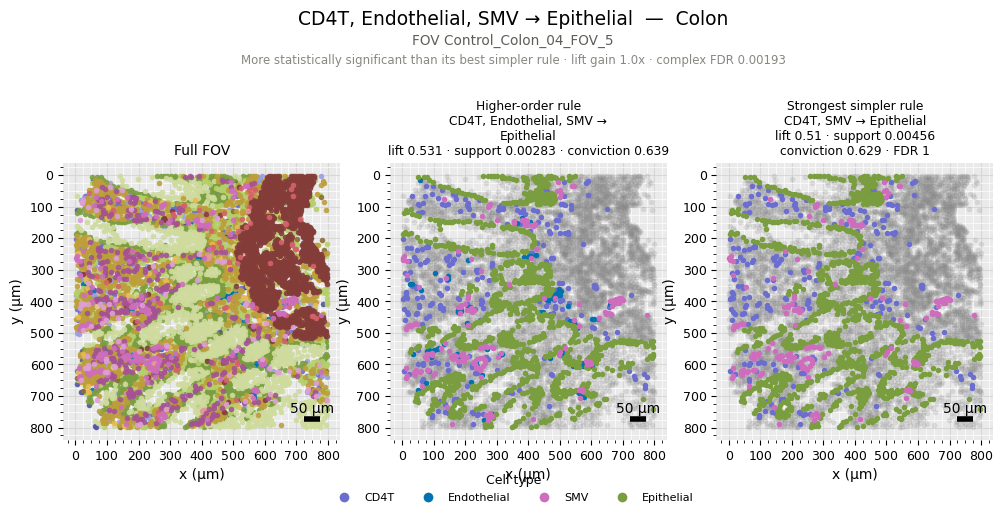

### New complex rules

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
39,"Muscle -> Fibroblast, Macrophage",con-complex,new,1.395137,1.25,17,nothing shorter was mined,1.116109
30,"Fibroblast, Neuron -> Goblet",ant-complex,new,1.451635,1.25,13,nothing shorter was mined,1.161308
8,"Endothelial, Fibroblast -> Goblet",ant-complex,new,1.659192,1.25,12,nothing shorter was mined,1.327354
47,"Muscle, SMV -> Fibroblast",ant-complex,new,1.432157,1.25,12,nothing shorter was mined,1.145725
48,"Muscle, SMV -> Macrophage",ant-complex,new,1.437918,1.25,11,nothing shorter was mined,1.150335
12,"Endothelial, SMV -> Epithelial",ant-complex,new,1.420394,1.25,11,nothing shorter was mined,1.136316
21,"Fibroblast, Mesenchymal_VIM -> Goblet",ant-complex,new,1.656839,1.25,10,nothing shorter was mined,1.325471
43,"Muscle -> Macrophage, SMV",con-complex,new,1.396679,1.25,10,nothing shorter was mined,1.117343
36,"Mesenchymal_VIM, Muscle -> Fibroblast",ant-complex,new,1.522690,1.25,9,nothing shorter was mined,1.218152
34,"Macrophage, Mast -> Goblet",ant-complex,new,1.408441,1.25,9,nothing shorter was mined,1.126753


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_new_avoid_gain_ranking.png


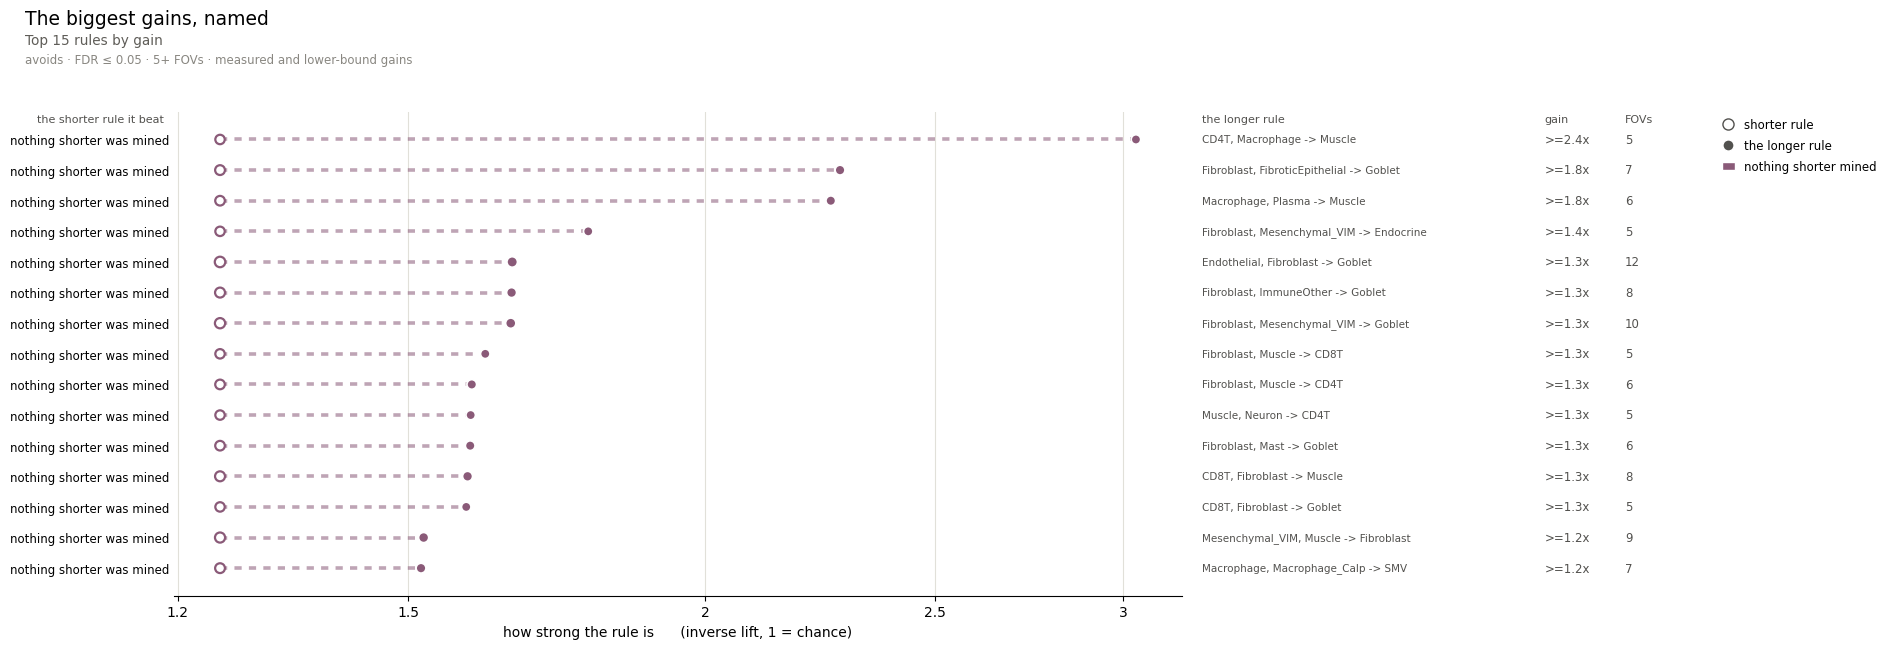

,FOV,rule,detail
0,GVHD_15_FOV_1,"Muscle -> Fibroblast, Macrophage",New rule · effect strength ≥ 1.3 · FDR 0.00656


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_muscle_avoids_fibroblast_macrophage_fov.png


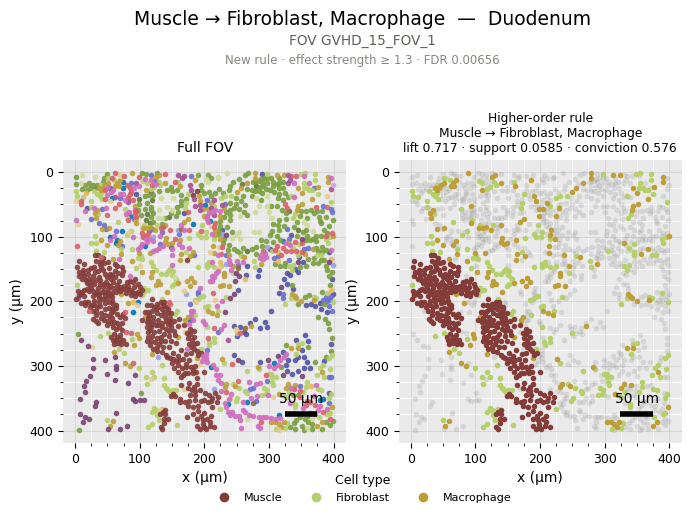

### Colon and duodenum

#### Colon

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
428,"Muscle -> CD4T, Treg",con-complex,stronger_effect,1000000.000000,6.105409,7,Muscle -> Treg,163789.186733
487,"Muscle -> Mast, Plasma",con-complex,stronger_effect,1000000.000000,6.804263,6,Muscle -> Plasma,146966.686053
450,"Muscle -> Endothelial, Plasma",con-complex,stronger_effect,500016.047227,8.530964,6,Muscle -> Plasma,58611.905172
181,"Goblet -> CD4T, CD8T, Neuron",con-complex,stronger_effect,1000000.000000,17.687965,7,"Goblet -> CD4T, Neuron",56535.615842
436,"Muscle -> CD8T, Goblet",con-complex,stronger_effect,1000000.000000,20.630149,8,Muscle -> Goblet,48472.747290
456,"Muscle -> Fibroblast, Goblet",con-complex,stronger_effect,1000000.000000,23.634847,5,Muscle -> Goblet,42310.406601
141,"Fibroblast, Muscle -> Goblet",ant-complex,stronger_effect,500012.333728,15.955172,6,Muscle -> Goblet,31338.573806
489,"Muscle -> Plasma, SMV",con-complex,stronger_effect,1000000.000000,34.751128,6,Muscle -> Plasma,28776.044484
67,"CD8T, Muscle -> Goblet",ant-complex,stronger_effect,1000000.000000,36.061081,6,Muscle -> Goblet,27730.726992
520,"Muscle, SMV -> Goblet",ant-complex,stronger_effect,1000000.000000,36.061081,8,Muscle -> Goblet,27730.726992


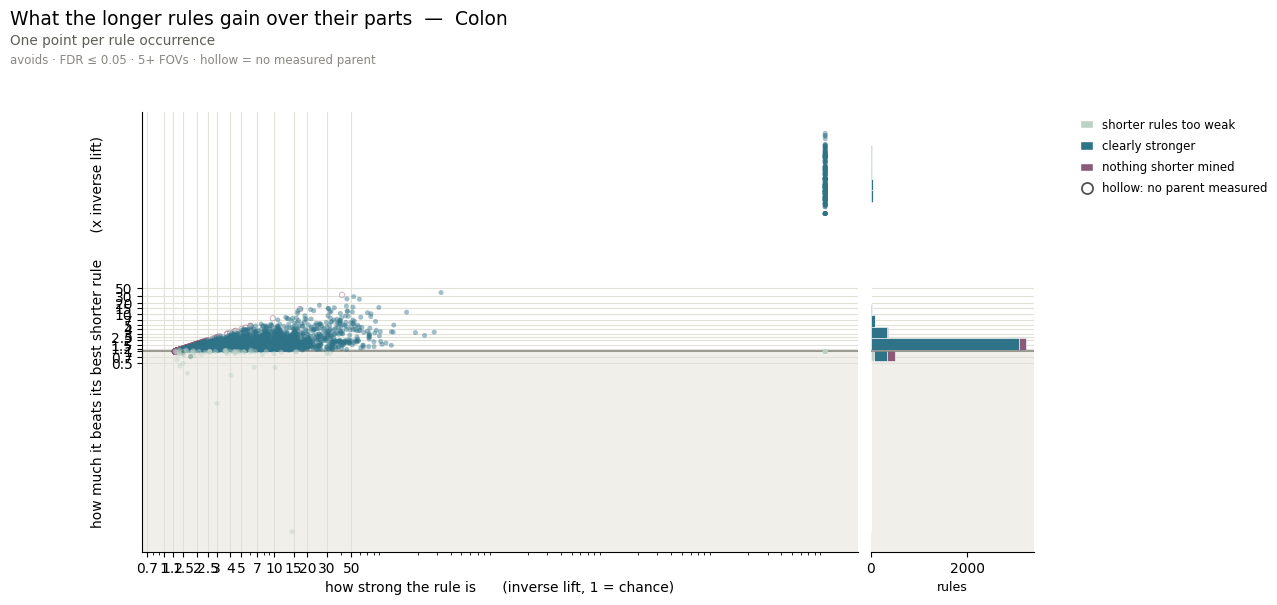

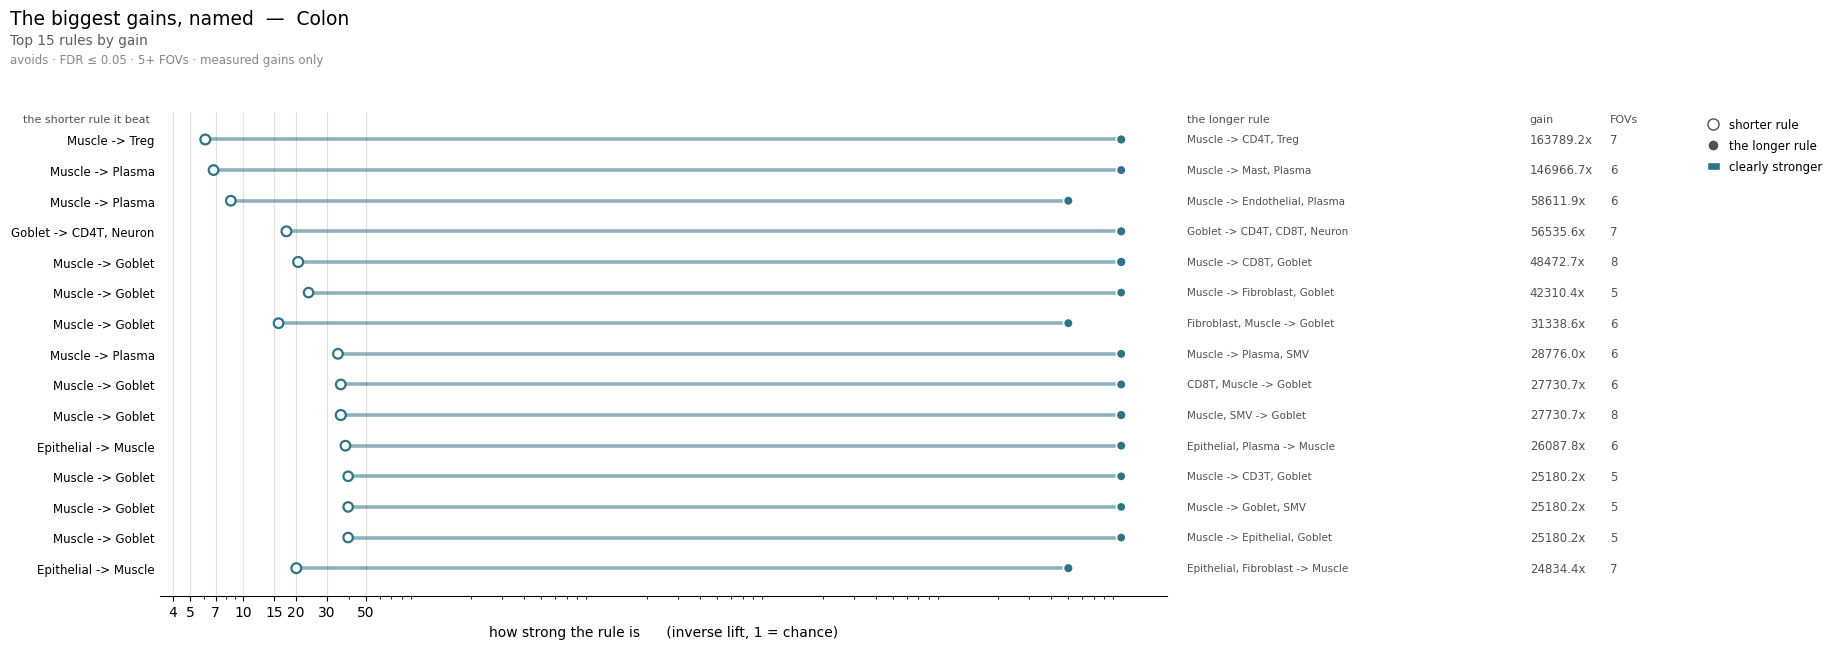

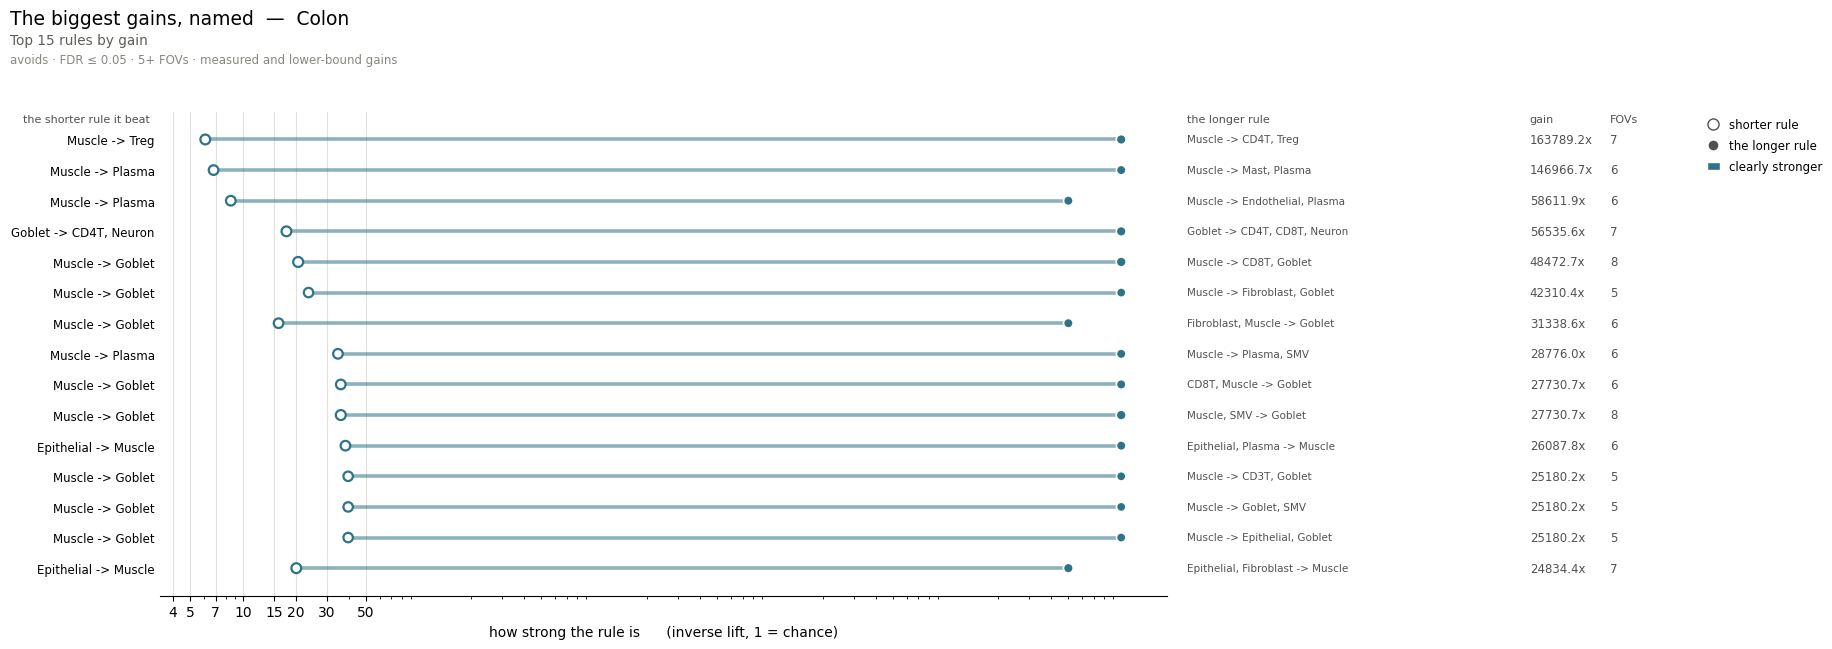

,FOV,rule,detail
0,Control_Colon_04_FOV_1,"Muscle -> Fibroblast, Monocyte",Stronger than its best simpler rule · lift gai...
1,Control_Colon_04_FOV_5,"CD4T, Endothelial, SMV -> Epithelial",More statistically significant than its best s...


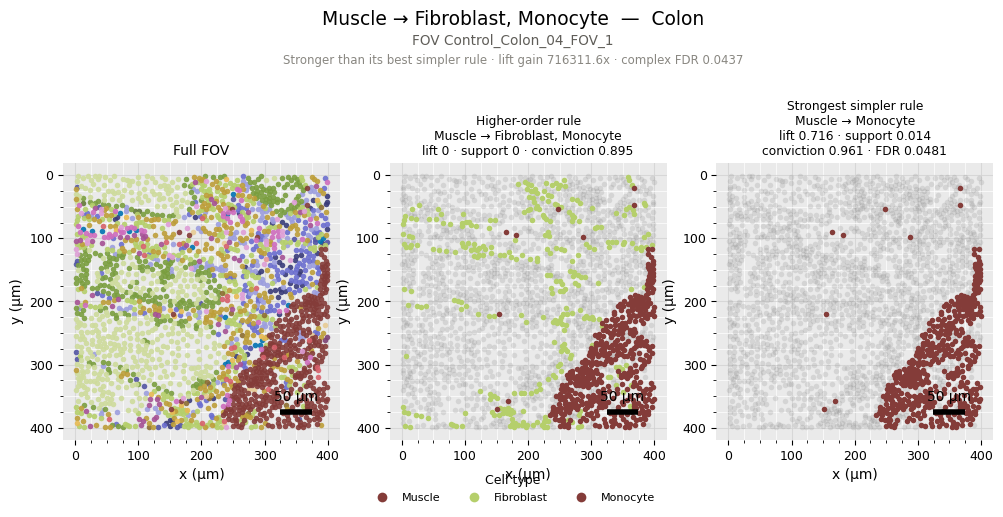

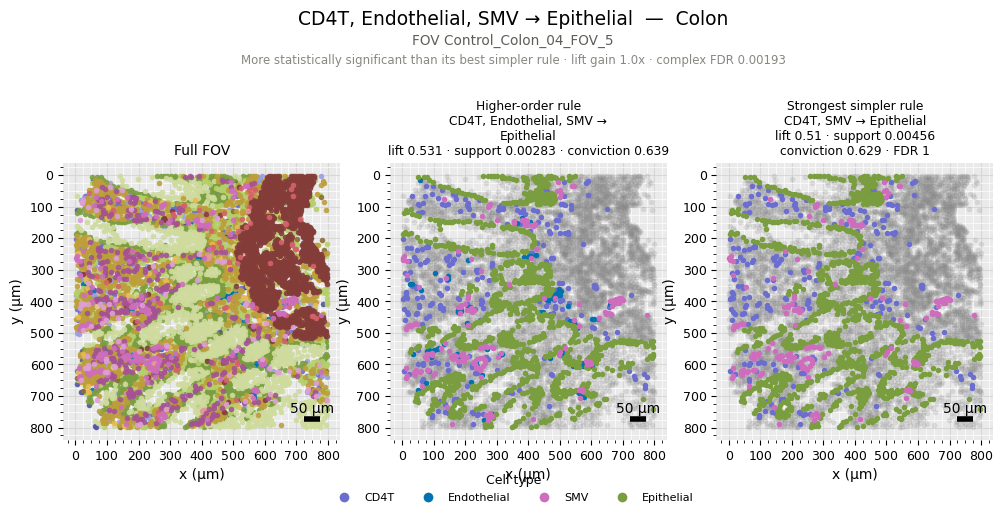

#### Duodenum

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
756,"Muscle -> Epithelial, Plasma",con-complex,stronger_effect,1000000.000000,13.111522,9,Muscle -> Epithelial,76268.798884
245,"Epithelial, Goblet -> Muscle",ant-complex,stronger_effect,1000000.000000,14.204139,34,Epithelial -> Muscle,70402.012555
560,"Macrophage, Muscle -> Goblet",ant-complex,stronger_effect,500017.690339,7.459123,6,Muscle -> Goblet,67034.376383
799,"Muscle -> Goblet, Plasma",con-complex,stronger_effect,1000000.000000,17.620744,6,Muscle -> Goblet,56751.294001
896,"Muscle, SMV -> Goblet",ant-complex,stronger_effect,1000000.000000,17.711701,5,Muscle -> Goblet,56459.850773
261,"Epithelial, Plasma -> Muscle",ant-complex,stronger_effect,1000000.000000,21.183779,15,Epithelial -> Muscle,47205.930270
262,"Epithelial, SMV -> Muscle",ant-complex,stronger_effect,500008.606372,12.985530,12,Epithelial -> Muscle,38505.058706
248,"Epithelial, Macrophage -> Muscle",ant-complex,stronger_effect,1000000.000000,44.649154,8,Epithelial -> Muscle,22396.840718
98,"CD8T, Epithelial -> Muscle",ant-complex,stronger_effect,1000000.000000,85.519188,5,Epithelial -> Muscle,11693.282166
849,"Muscle -> Neuron, Plasma_CD38",con-complex,stronger_effect,19.933857,2.986977,13,Muscle -> Plasma_CD38,6.673588


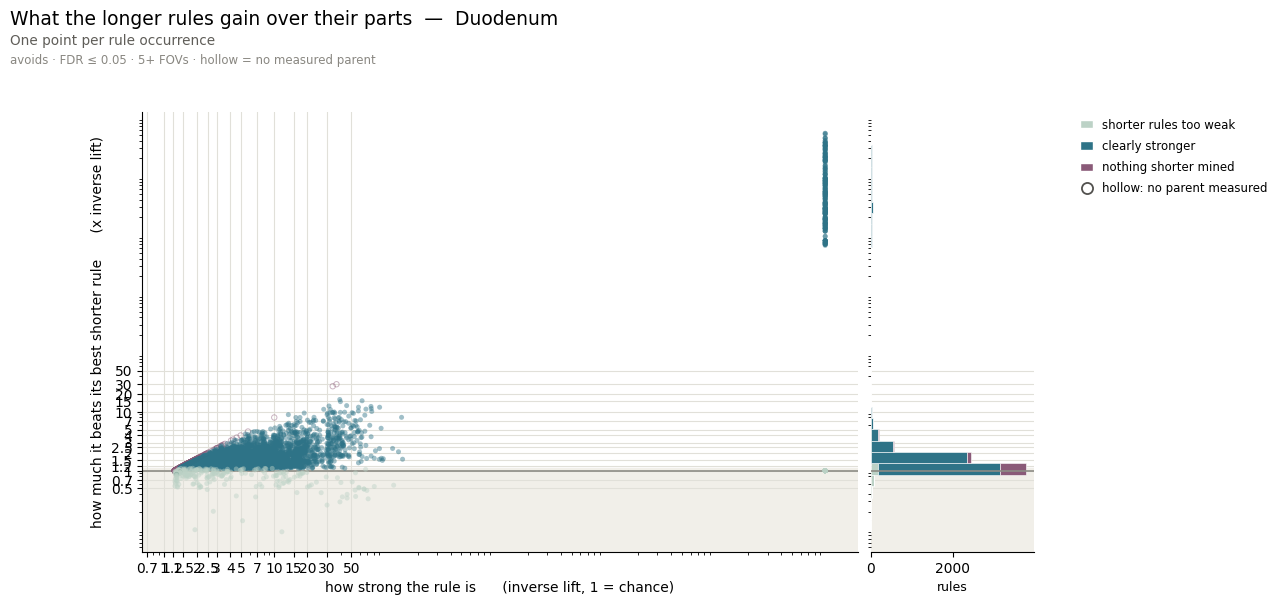

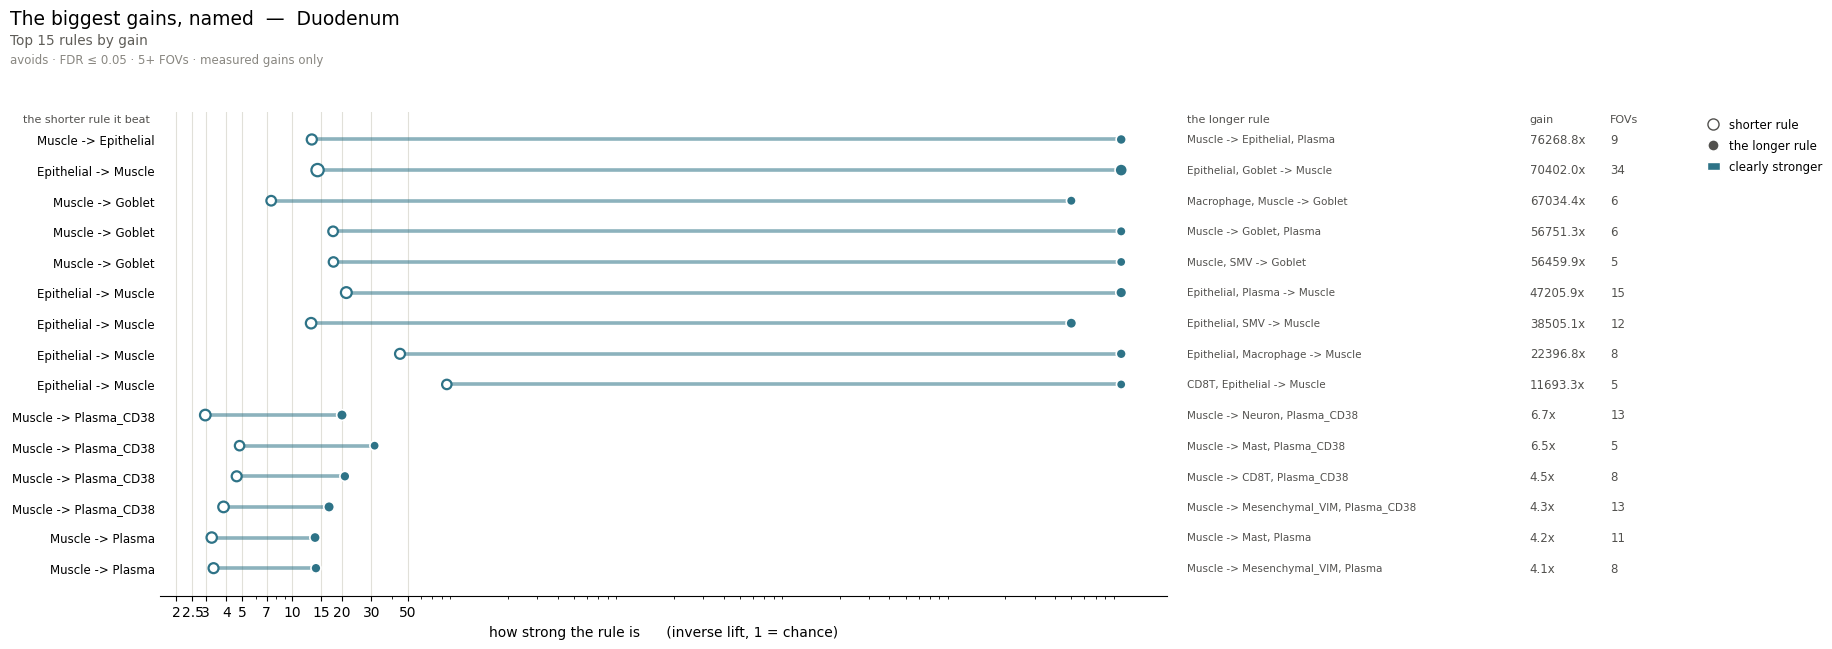

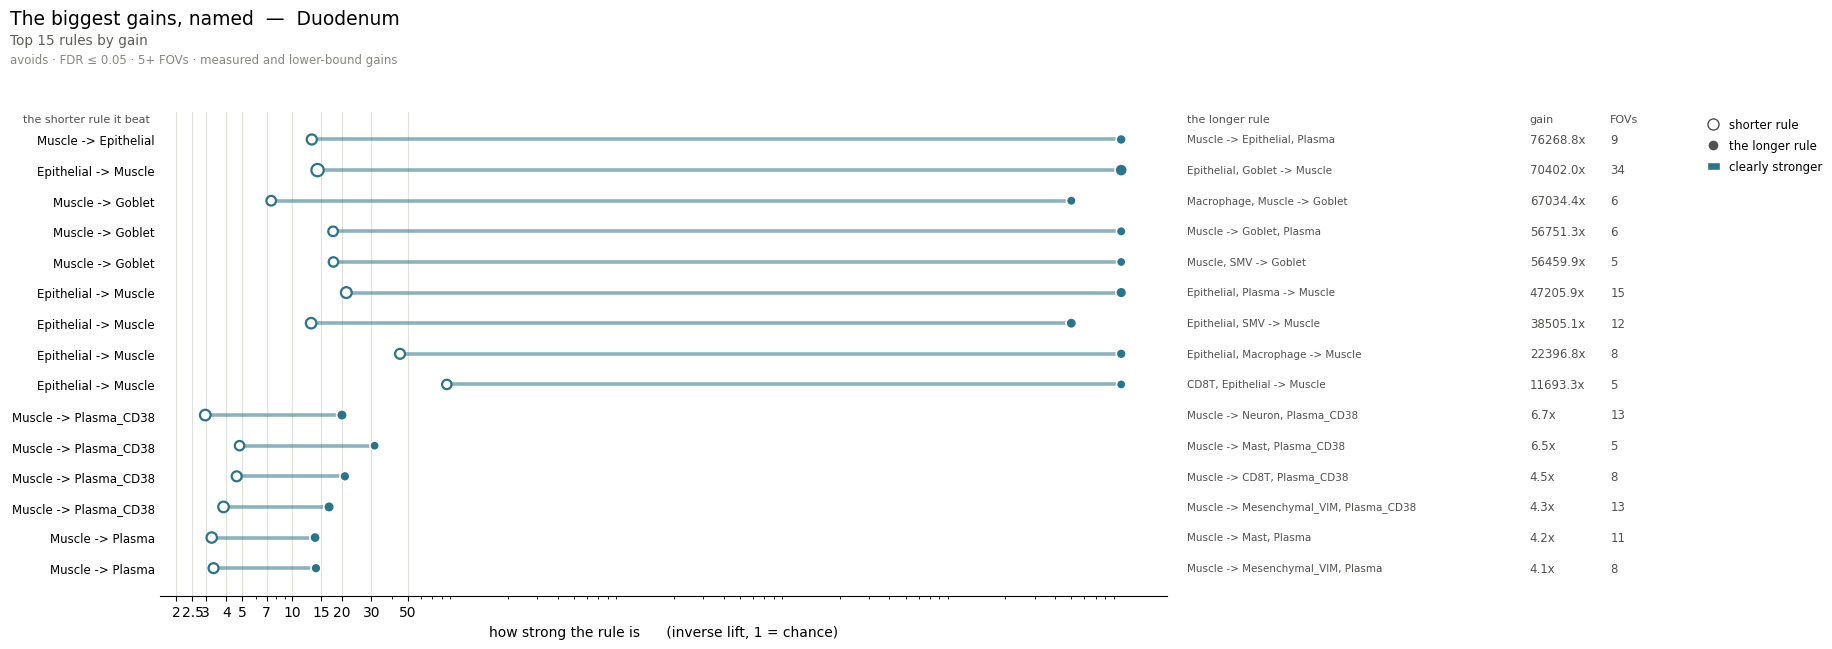

,FOV,rule,detail
0,GVHD_16_FOV_3,"Muscle, Neuron -> CD4T",Stronger than its best simpler rule · lift gai...
1,GVHD_27_FOV_3,"Endothelial, SMV -> Epithelial",More statistically significant than its best s...


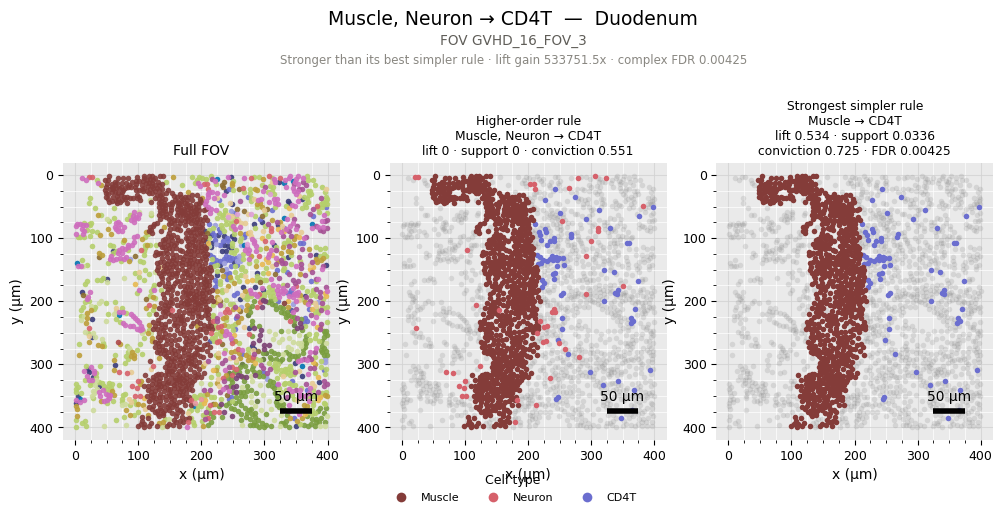

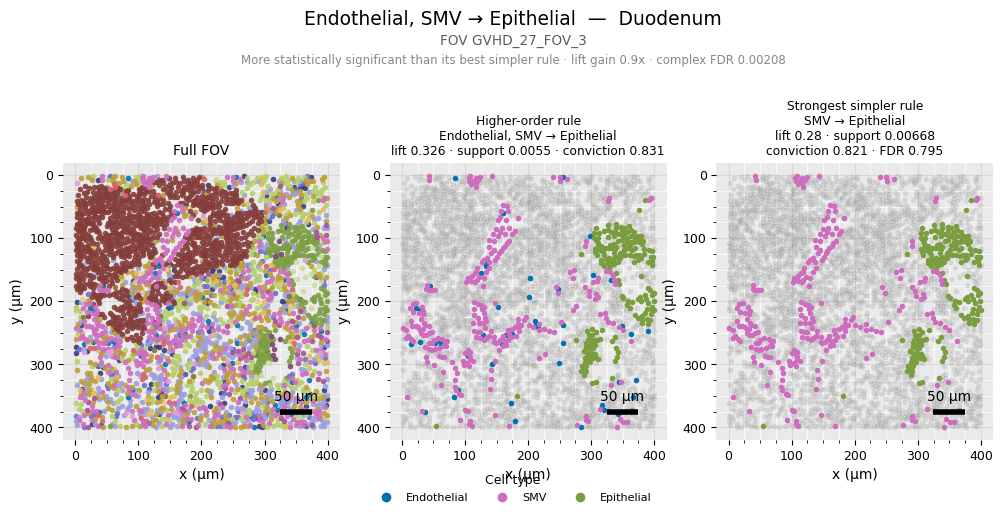

In [14]:
kind = "avoids"
rules = df_results[df_results["Kind"] == kind]

display(Markdown("### Rule counts"))
display(rule_counts(rules))

display(Markdown("### Verdicts"))
display(class_split(rules))
show_class_split(rules, kind)
show_class_split(
    rules, kind, max_fdr=MAX_FDR, save=TEX_CLASS_EXPORTS.get(kind),
)
show_class_split(rules, kind, split_by=SCORE_COLUMN, max_fdr=MAX_FDR)
for organ in ORGAN_ORDER:
    show_class_split(
        rules[rules["Organ"] == organ], kind,
        max_fdr=MAX_FDR, organ=organ,
    )

display(Markdown("### Strength gains"))
gains = gain_table(rules)
gain_rows = gain_table(rules, per="fov")
display(gains.head(TOP_N))
show_gain_scatter(gain_rows, kind)
show_gain_dumbbell(gains, kind)
show_gain_dumbbell(gains, kind, include_new=True)
show_fov_examples(gains, gain_rows)

display(Markdown("### New complex rules"))
new_table, new_rows = new_results(rules)
display(new_table.head(TOP_N))
show_gain_dumbbell(
    new_table, kind, include_new=True, save=TEX_NEW_GAIN_EXPORTS.get(kind),
)
exports = {
    rule: filename
    for (export_kind, rule), filename in TEX_NEW_FOV_EXPORTS.items()
    if export_kind == kind
}
show_new_fov_examples(new_table, new_rows, exports=exports)

display(Markdown("### Colon and duodenum"))
for organ in ORGAN_ORDER:
    display(Markdown(f"#### {organ}"))
    organ_rules = rules[rules["Organ"] == organ]
    organ_gains = gain_table(organ_rules)
    organ_rows = gain_table(organ_rules, per="fov")
    display(organ_gains.head(TOP_N))
    show_gain_scatter(organ_rows, kind, organ=organ)
    show_gain_dumbbell(organ_gains, kind, organ=organ)
    show_gain_dumbbell(
        organ_gains, kind, include_new=True, organ=organ,
    )
    show_fov_examples(organ_gains, organ_rows)
